In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style("whitegrid")

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [8]:
gen_df     = pd.read_csv("Plant_1_Generation_Data.csv")
weather_df = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

print(f"Generation Data  : {gen_df.shape[0]:,} rows × {gen_df.shape[1]} cols")
print(f"Weather Data     : {weather_df.shape[0]:,} rows × {weather_df.shape[1]} cols")
print("\n--- Generation Sample ---")


gen_df.head()

Generation Data  : 68,778 rows × 7 cols
Weather Data     : 3,182 rows × 6 cols

--- Generation Sample ---


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [7]:
weather_df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [9]:
print("=== GENERATION DATA INFO ===")
gen_df.info()
print("\n=== WEATHER DATA INFO ===")
weather_df.info()

=== GENERATION DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB

=== WEATHER DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null 

In [10]:
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'],
                                     format='%d-%m-%Y %H:%M',
                                     dayfirst=True)

# Weather data has standard ISO format
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

# Verify
print("Generation datetime range :",
      gen_df['DATE_TIME'].min(), "→", gen_df['DATE_TIME'].max())
print("Weather datetime range    :",
      weather_df['DATE_TIME'].min(), "→", weather_df['DATE_TIME'].max())
print("Generation freq check (sample):", gen_df['DATE_TIME'].drop_duplicates().sort_values().diff().mode()[0])

Generation datetime range : 2020-05-15 00:00:00 → 2020-06-17 23:45:00
Weather datetime range    : 2020-05-15 00:00:00 → 2020-06-17 23:45:00
Generation freq check (sample): 0 days 00:15:00


In [14]:
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'],
                                     format='%d-%m-%Y %H:%M',
                                     dayfirst=True)

# Weather data has standard ISO format
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

# Verify
print("Generation datetime range :",
      gen_df['DATE_TIME'].min(), "→", gen_df['DATE_TIME'].max())
print("Weather datetime range    :",
      weather_df['DATE_TIME'].min(), "→", weather_df['DATE_TIME'].max())
print("Generation freq check (sample):", gen_df['DATE_TIME'].drop_duplicates().sort_values().diff().mode()[0])


# ── CELL 5: Null & Duplicate Check ──────────────────────────
print("=== NULLS ===")
print("Generation:\n", gen_df.isnull().sum())
print("\nWeather:\n", weather_df.isnull().sum())

print("\n=== DUPLICATES ===")
gen_dups = gen_df.duplicated(subset=['DATE_TIME','SOURCE_KEY']).sum()
weather_dups = weather_df.duplicated(subset=['DATE_TIME','SOURCE_KEY']).sum()
print(f"Generation duplicates : {gen_dups}")
print(f"Weather duplicates    : {weather_dups}")

# Drop duplicates if any
gen_df     = gen_df.drop_duplicates(subset=['DATE_TIME','SOURCE_KEY'])
weather_df = weather_df.drop_duplicates(subset=['DATE_TIME','SOURCE_KEY'])


# ── CELL 6: Outlier Detection & Cleaning ────────────────────
print("=== DESCRIPTIVE STATS (Generation) ===")
display(gen_df[['DC_POWER','AC_POWER','DAILY_YIELD','TOTAL_YIELD']].describe().round(2))

# Flag negative power values (physically impossible)
neg_dc = (gen_df['DC_POWER'] < 0).sum()
neg_ac = (gen_df['AC_POWER'] < 0).sum()
print(f"\nNegative DC_POWER rows : {neg_dc}")
print(f"Negative AC_POWER rows : {neg_ac}")

# Clip negatives to 0
gen_df['DC_POWER'] = gen_df['DC_POWER'].clip(lower=0)
gen_df['AC_POWER'] = gen_df['AC_POWER'].clip(lower=0)

# Flag AC > DC (impossible without transformer step-up — data quality issue)
gen_df['AC_GT_DC_FLAG'] = gen_df['AC_POWER'] > gen_df['DC_POWER']
print(f"Rows where AC > DC     : {gen_df['AC_GT_DC_FLAG'].sum()}")

# IQR-based outlier flag for DC_POWER (daytime only)
daytime = gen_df[gen_df['DC_POWER'] > 0].copy()
Q1, Q3 = daytime['DC_POWER'].quantile(0.25), daytime['DC_POWER'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR
gen_df['DC_OUTLIER_FLAG'] = (gen_df['DC_POWER'] > upper_bound)
print(f"DC_POWER outlier rows  : {gen_df['DC_OUTLIER_FLAG'].sum()} (threshold: {upper_bound:.1f} W)")


# ── CELL 7: Feature Engineering ─────────────────────────────
# Time features
gen_df['DATE']   = gen_df['DATE_TIME'].dt.date
gen_df['HOUR']   = gen_df['DATE_TIME'].dt.hour
gen_df['MINUTE'] = gen_df['DATE_TIME'].dt.minute
gen_df['DAY_OF_WEEK'] = gen_df['DATE_TIME'].dt.day_name()

# Conversion efficiency: AC/DC ratio (avoid division by zero)
gen_df['CONVERSION_EFFICIENCY'] = np.where(
    gen_df['DC_POWER'] > 0,
    gen_df['AC_POWER'] / gen_df['DC_POWER'],
    np.nan
)

# Boolean: is it daylight (DC > 0)?
gen_df['IS_DAYTIME'] = gen_df['DC_POWER'] > 0

# Inverter-level daily cumulative yield (reset per inverter per day)
gen_df = gen_df.sort_values(['SOURCE_KEY','DATE_TIME'])
gen_df['DAILY_YIELD_CALC'] = gen_df.groupby(['SOURCE_KEY', gen_df['DATE_TIME'].dt.date])['AC_POWER'].cumsum() * (15/60)

print("✅ Feature engineering complete")
display(gen_df[['DATE_TIME','SOURCE_KEY','DC_POWER','AC_POWER',
                'CONVERSION_EFFICIENCY','IS_DAYTIME','DAILY_YIELD_CALC']].head(8))


# ── CELL 8: Synthetic SCADA Columns ─────────────────────────
# Simulate setpoints and operational constraints (as would exist in real SCADA)
np.random.seed(42)

# Setpoint: target AC power per inverter based on irradiation-adjusted capacity
# Capacity ~1400W max per inverter; setpoint = 92% of max during daytime
gen_df['SETPOINT_AC_POWER'] = np.where(
    gen_df['IS_DAYTIME'],
    (gen_df['AC_POWER'].replace(0, np.nan)
     .groupby(gen_df['DATE_TIME'].dt.date)
     .transform('max')
     .fillna(0) * 0.92 + np.random.normal(0, 15, len(gen_df))).clip(0),
    0.0
)

# Deviation from setpoint
gen_df['DEVIATION_FROM_SETPOINT'] = gen_df['AC_POWER'] - gen_df['SETPOINT_AC_POWER']
gen_df['DEVIATION_PCT'] = np.where(
    gen_df['SETPOINT_AC_POWER'] > 0,
    (gen_df['DEVIATION_FROM_SETPOINT'] / gen_df['SETPOINT_AC_POWER']) * 100,
    np.nan
)

# Constraint flags
gen_df['UNDERPERFORMANCE_FLAG'] = gen_df['DEVIATION_PCT'] < -10   # >10% below setpoint
gen_df['OVERLOAD_FLAG']         = gen_df['DEVIATION_PCT'] > 15    # >15% above setpoint
gen_df['CURTAILMENT_FLAG']      = (gen_df['IS_DAYTIME']) & (gen_df['AC_POWER'] < 50)  # daytime near-zero

print("✅ SCADA simulation columns added")
print(f"Underperformance events : {gen_df['UNDERPERFORMANCE_FLAG'].sum():,}")
print(f"Overload events         : {gen_df['OVERLOAD_FLAG'].sum():,}")
print(f"Curtailment events      : {gen_df['CURTAILMENT_FLAG'].sum():,}")


# ── CELL 9: Merge Generation + Weather ──────────────────────
# Weather has a single sensor key; broadcast to all inverters by timestamp
weather_agg = weather_df.groupby('DATE_TIME').agg(
    AMBIENT_TEMPERATURE=('AMBIENT_TEMPERATURE','mean'),
    MODULE_TEMPERATURE =('MODULE_TEMPERATURE','mean'),
    IRRADIATION        =('IRRADIATION','mean')
).reset_index()

merged_df = pd.merge(gen_df, weather_agg, on='DATE_TIME', how='left')

# Fill any unmatched weather rows with interpolation
merged_df = merged_df.set_index('DATE_TIME')
merged_df[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']] = \
    merged_df[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']].interpolate(method='time')
merged_df = merged_df.reset_index()

print(f"✅ Merged dataset shape: {merged_df.shape}")
print(f"   Null weather values after merge+interpolate: "
      f"{merged_df[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']].isnull().sum().sum()}")
display(merged_df.head(3))



Generation datetime range : 2020-05-15 00:00:00 → 2020-06-17 23:45:00
Weather datetime range    : 2020-05-15 00:00:00 → 2020-06-17 23:45:00
Generation freq check (sample): 0 days 00:15:00
=== NULLS ===
Generation:
 DATE_TIME                      0
PLANT_ID                       0
SOURCE_KEY                     0
DC_POWER                       0
AC_POWER                       0
DAILY_YIELD                    0
TOTAL_YIELD                    0
AC_GT_DC_FLAG                  0
DC_OUTLIER_FLAG                0
DATE                           0
HOUR                           0
MINUTE                         0
DAY_OF_WEEK                    0
CONVERSION_EFFICIENCY      31951
IS_DAYTIME                     0
DAILY_YIELD_CALC               0
SETPOINT_AC_POWER              0
DEVIATION_FROM_SETPOINT        0
DEVIATION_PCT              31951
UNDERPERFORMANCE_FLAG          0
OVERLOAD_FLAG                  0
CURTAILMENT_FLAG               0
dtype: int64

Weather:
 DATE_TIME              0
PLANT_ID  

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.00,68778.00,68778.00,68778.00
mean,3147.43,307.80,3295.97,6978711.76
std,4036.46,394.40,3145.18,416271.98
min,0.00,0.00,0.00,6183645.00
25%,0.00,0.00,0.00,6512002.54
50%,429.00,41.49,2658.71,7146685.00
75%,6366.96,623.62,6274.00,7268705.91
max,14471.12,1410.95,9163.00,7846821.00



Negative DC_POWER rows : 0
Negative AC_POWER rows : 0
Rows where AC > DC     : 0
DC_POWER outlier rows  : 0 (threshold: 28458.5 W)
✅ Feature engineering complete


,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER,CONVERSION_EFFICIENCY,IS_DAYTIME,DAILY_YIELD_CALC
0,2020-05-15 00:00:00,1BY6WEcLGh8j5v7,0.0,0.0,NaN,False,0.0
21,2020-05-15 00:15:00,1BY6WEcLGh8j5v7,0.0,0.0,NaN,False,0.0
42,2020-05-15 00:30:00,1BY6WEcLGh8j5v7,0.0,0.0,NaN,False,0.0
63,2020-05-15 00:45:00,1BY6WEcLGh8j5v7,0.0,0.0,NaN,False,0.0
84,2020-05-15 01:00:00,1BY6WEcLGh8j5v7,0.0,0.0,NaN,False,0.0
106,2020-05-15 01:15:00,1BY6WEcLGh8j5v7,0.0,0.0,NaN,False,0.0
127,2020-05-15 01:30:00,1BY6WEcLGh8j5v7,0.0,0.0,NaN,False,0.0
148,2020-05-15 01:45:00,1BY6WEcLGh8j5v7,0.0,0.0,NaN,False,0.0


✅ SCADA simulation columns added
Underperformance events : 32,950
Overload events         : 0
Curtailment events      : 2,861
✅ Merged dataset shape: (68778, 25)
   Null weather values after merge+interpolate: 0


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AC_GT_DC_FLAG,DC_OUTLIER_FLAG,DATE,...,DAILY_YIELD_CALC,SETPOINT_AC_POWER,DEVIATION_FROM_SETPOINT,DEVIATION_PCT,UNDERPERFORMANCE_FLAG,OVERLOAD_FLAG,CURTAILMENT_FLAG,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,False,False,2020-05-15,...,0.0,0.0,0.0,NaN,False,False,False,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,False,False,2020-05-15,...,0.0,0.0,0.0,NaN,False,False,False,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,False,False,2020-05-15,...,0.0,0.0,0.0,NaN,False,False,False,24.935753,22.592306,0.0


In [15]:
# ── CELL 10: Plant-Level Aggregation ────────────────────────
# Aggregate all inverters → plant-level per timestamp
plant_ts = merged_df.groupby('DATE_TIME').agg(
    TOTAL_DC_POWER          =('DC_POWER','sum'),
    TOTAL_AC_POWER          =('AC_POWER','sum'),
    TOTAL_SETPOINT          =('SETPOINT_AC_POWER','sum'),
    AVG_CONVERSION_EFF      =('CONVERSION_EFFICIENCY','mean'),
    AMBIENT_TEMPERATURE     =('AMBIENT_TEMPERATURE','first'),
    MODULE_TEMPERATURE      =('MODULE_TEMPERATURE','first'),
    IRRADIATION             =('IRRADIATION','first'),
    UNDERPERFORMANCE_COUNT  =('UNDERPERFORMANCE_FLAG','sum'),
    CURTAILMENT_COUNT       =('CURTAILMENT_FLAG','sum'),
    ACTIVE_INVERTERS        =('IS_DAYTIME','sum')
).reset_index()

plant_ts['PLANT_DEVIATION_PCT'] = np.where(
    plant_ts['TOTAL_SETPOINT'] > 0,
    (plant_ts['TOTAL_AC_POWER'] - plant_ts['TOTAL_SETPOINT']) / plant_ts['TOTAL_SETPOINT'] * 100,
    np.nan
)

plant_ts['DATE'] = plant_ts['DATE_TIME'].dt.date
print(f"✅ Plant-level time series: {plant_ts.shape}")
display(plant_ts.head(4))


# ── CELL 11: Daily KPI Summary ───────────────────────────────
daily_kpis = plant_ts.groupby('DATE').agg(
    TOTAL_ENERGY_KWH        =('TOTAL_AC_POWER', lambda x: x.sum() * 15/60 / 1000),
    EXPECTED_ENERGY_KWH     =('TOTAL_SETPOINT', lambda x: x.sum() * 15/60 / 1000),
    AVG_IRRADIATION         =('IRRADIATION','mean'),
    AVG_AMBIENT_TEMP        =('AMBIENT_TEMPERATURE','mean'),
    AVG_MODULE_TEMP         =('MODULE_TEMPERATURE','mean'),
    AVG_CONVERSION_EFF      =('AVG_CONVERSION_EFF','mean'),
    PEAK_AC_POWER_KW        =('TOTAL_AC_POWER', lambda x: x.max() / 1000),
    TOTAL_UNDERPERFORMANCE  =('UNDERPERFORMANCE_COUNT','sum'),
    TOTAL_CURTAILMENT       =('CURTAILMENT_COUNT','sum')
).reset_index()

daily_kpis['PERFORMANCE_RATIO'] = (
    daily_kpis['TOTAL_ENERGY_KWH'] / daily_kpis['EXPECTED_ENERGY_KWH']
).clip(0, 1.2)

daily_kpis['ENERGY_LOSS_KWH'] = (
    daily_kpis['EXPECTED_ENERGY_KWH'] - daily_kpis['TOTAL_ENERGY_KWH']
).clip(lower=0)

print("=== DAILY KPI SUMMARY ===")
display(daily_kpis.describe().round(2))


✅ Plant-level time series: (3158, 13)


,DATE_TIME,TOTAL_DC_POWER,TOTAL_AC_POWER,TOTAL_SETPOINT,AVG_CONVERSION_EFF,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,UNDERPERFORMANCE_COUNT,CURTAILMENT_COUNT,ACTIVE_INVERTERS,PLANT_DEVIATION_PCT,DATE
0,2020-05-15 00:00:00,0.0,0.0,0.0,NaN,25.184316,22.857507,0.0,0,0,0,NaN,2020-05-15
1,2020-05-15 00:15:00,0.0,0.0,0.0,NaN,25.084589,22.761668,0.0,0,0,0,NaN,2020-05-15
2,2020-05-15 00:30:00,0.0,0.0,0.0,NaN,24.935753,22.592306,0.0,0,0,0,NaN,2020-05-15
3,2020-05-15 00:45:00,0.0,0.0,0.0,NaN,24.846130,22.360852,0.0,0,0,0,NaN,2020-05-15


=== DAILY KPI SUMMARY ===


,TOTAL_ENERGY_KWH,EXPECTED_ENERGY_KWH,AVG_IRRADIATION,AVG_AMBIENT_TEMP,AVG_MODULE_TEMP,AVG_CONVERSION_EFF,PEAK_AC_POWER_KW,TOTAL_UNDERPERFORMANCE,TOTAL_CURTAILMENT,PERFORMANCE_RATIO,ENERGY_LOSS_KWH
count,34.00,34.00,34.00,34.00,34.00,34.0,34.00,34.00,34.00,34.00,34.00
mean,155.66,324.37,0.23,25.60,31.31,0.1,26.81,969.12,84.15,0.48,168.71
std,21.58,30.84,0.05,1.20,2.62,0.0,1.72,116.29,19.25,0.06,28.99
min,117.74,228.21,0.16,23.85,27.59,0.1,21.86,511.00,22.00,0.36,96.94
25%,136.71,318.52,0.20,24.76,29.48,0.1,26.26,926.25,78.00,0.44,153.80
50%,157.98,331.89,0.23,25.22,30.70,0.1,27.12,1021.00,88.00,0.48,168.68
75%,174.31,344.52,0.26,26.82,32.56,0.1,27.86,1043.25,89.75,0.53,192.71
max,192.89,362.68,0.36,27.94,38.14,0.1,29.15,1068.00,120.00,0.60,225.47


=== INVERTER PERFORMANCE RANKING ===


,SOURCE_KEY,TOTAL_ENERGY_KWH,AVG_DC_POWER,AVG_AC_POWER,AVG_EFFICIENCY,UNDERPERF_EVENTS,CURTAILMENT_EVENTS,TOTAL_READINGS,UNDERPERF_RATE_PCT
1,adLQvlD726eNBSB,249.281289,6077.343003,594.234301,0.097711,1463,130,1678,87.19
2,1IF53ai7Xc0U56Y,246.001788,6011.316834,587.817893,0.097717,1479,128,1674,88.35
3,VHMLBKoKgIrUVDU,245.862250,5997.168354,586.433513,0.097714,1471,127,1677,87.72
4,3PZuoBAID5Wc2HD,245.517052,6010.249472,587.712872,0.097714,1474,130,1671,88.21
5,McdE0feGgRqW7Ca,245.270177,5985.754077,585.370351,0.097719,1472,130,1676,87.83
6,ZnxXDlPa8U1GXgE,244.411079,5965.038781,583.319998,0.097718,1488,126,1676,88.78
7,iCRJl6heRkivqQ3,244.172125,5959.268115,582.749701,0.097716,1496,128,1676,89.26
8,uHbuxQJl8lW7ozc,244.115503,5954.300984,582.267151,0.097716,1501,130,1677,89.51
9,zVJPv84UY57bAof,243.419475,5944.434154,581.300240,0.097715,1489,129,1675,88.90
10,wCURE6d3bPkepu2,242.315050,5917.386286,578.662806,0.097717,1476,130,1675,88.12


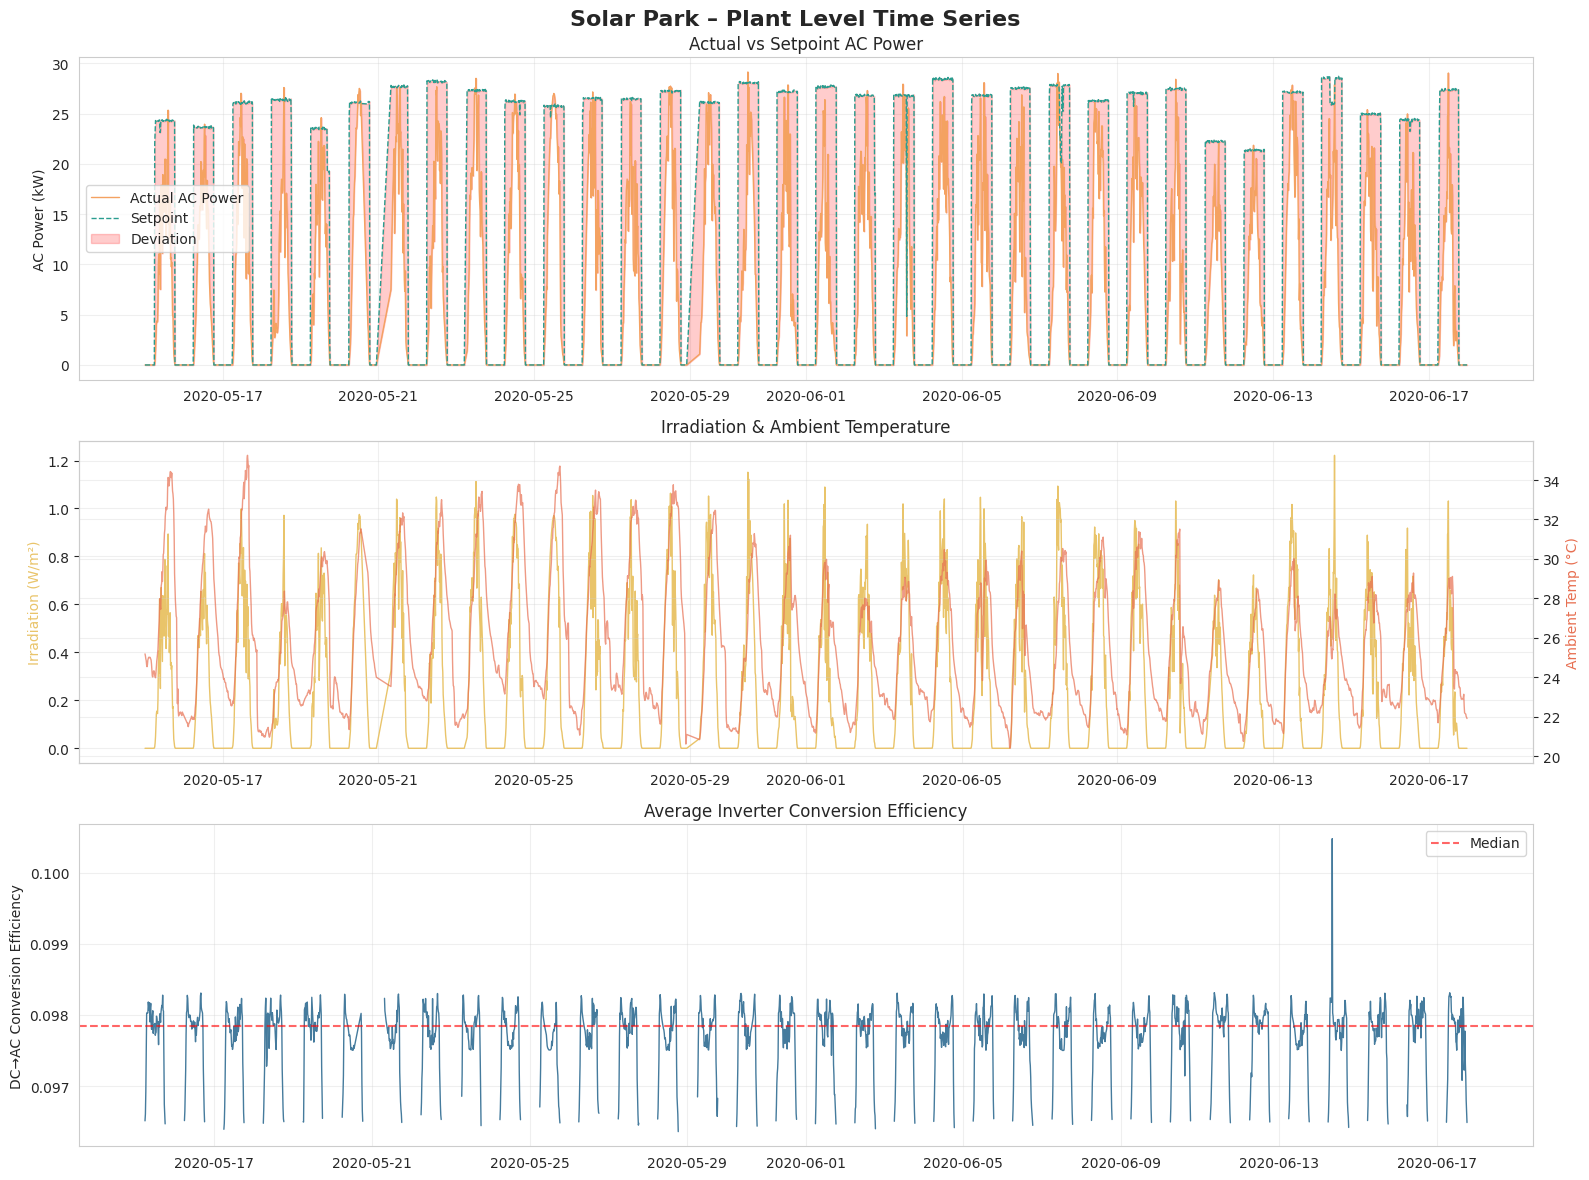

✅ Plot saved: plant_timeseries.png


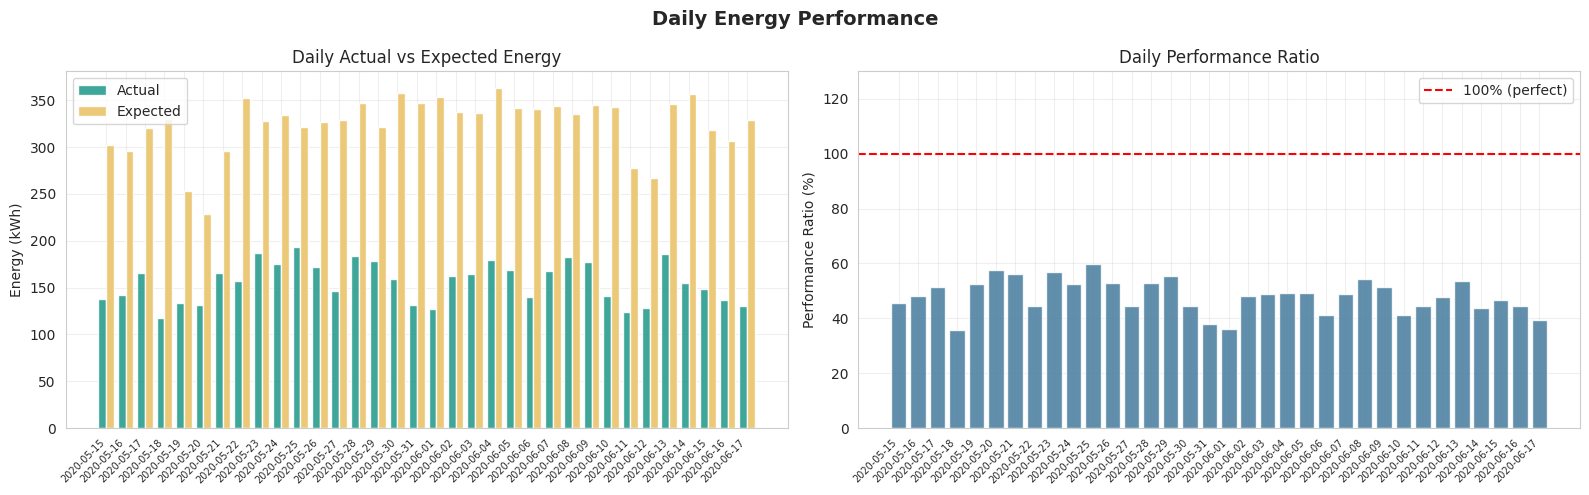

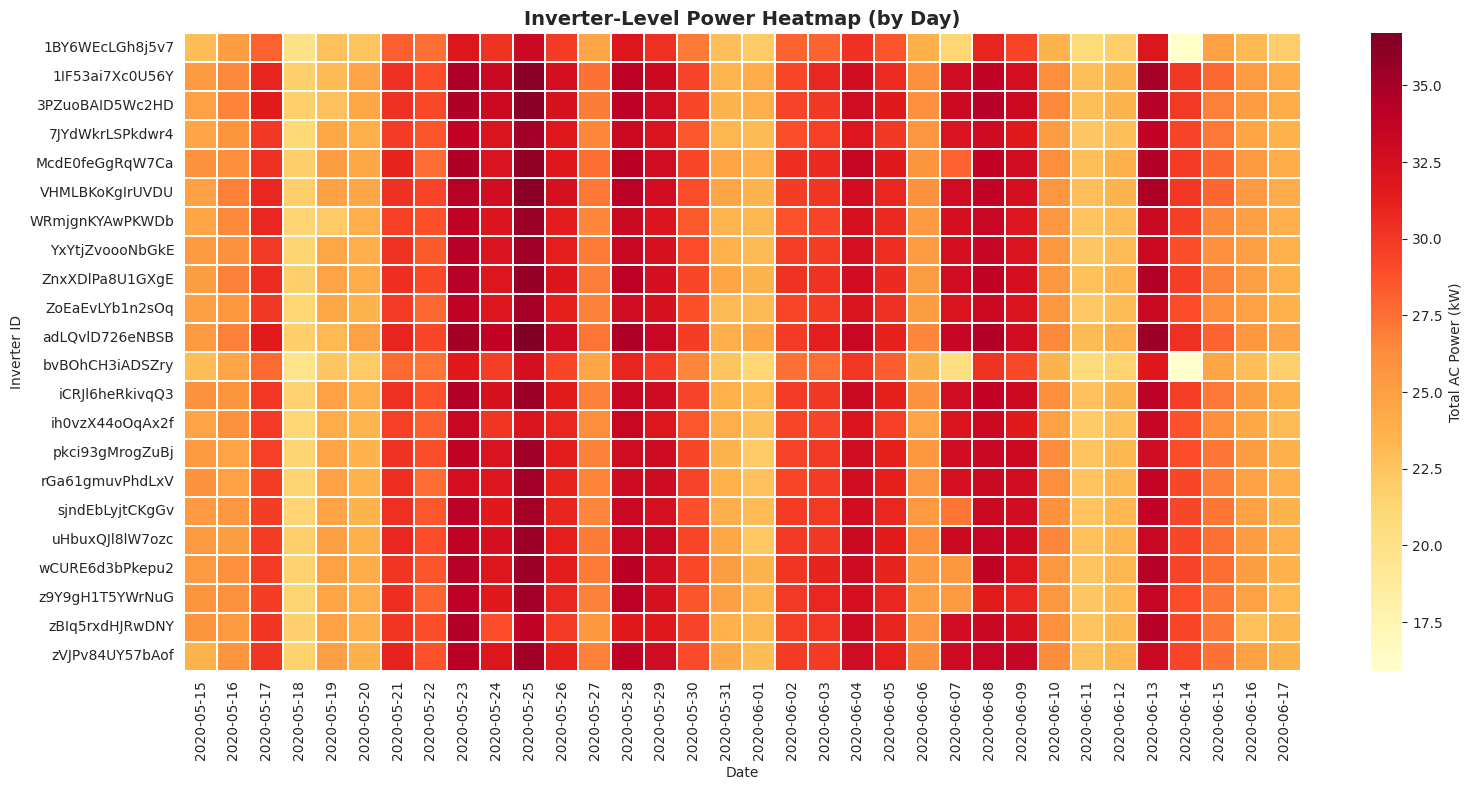

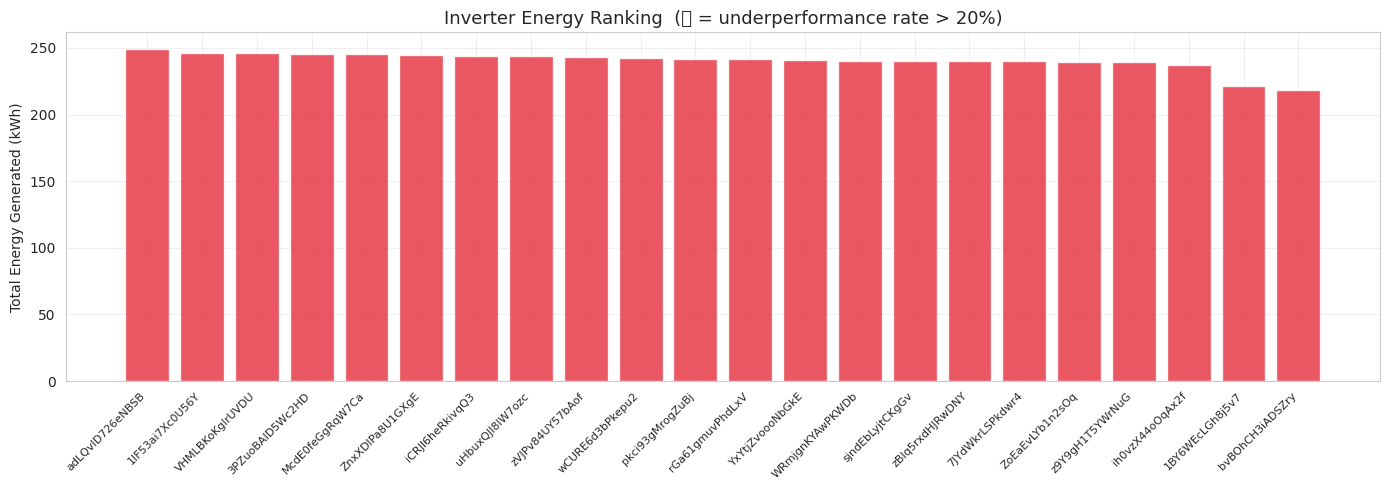

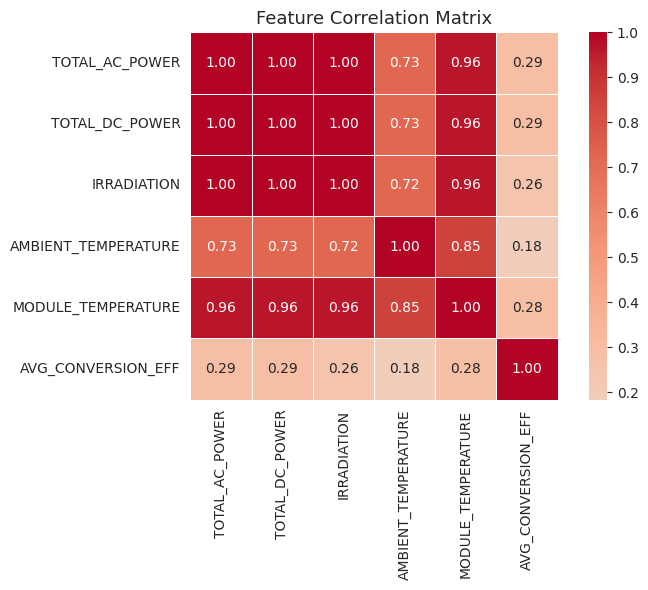

✅ All cleaned datasets exported:
   • Plant1_Cleaned_Merged.csv       — full inverter-level merged data
   • Plant1_Daily_KPIs.csv           — daily performance summary
   • Plant1_Inverter_KPIs.csv        — inverter ranking & health
   • Plant1_PlantLevel_TimeSeries.csv — aggregated plant-level series
       SOLAR PARK – PIPELINE SUMMARY REPORT
  Data Period      : 2020-05-15 → 2020-06-17
  Total Inverters  : 22
  Total Records    : 68,778
  Sampling Rate    : 15 minutes

  Total Energy (Actual)   : 5,292.5 kWh
  Total Energy (Expected) : 11,028.7 kWh
  Total Energy Loss       : 5,736.2 kWh
  Avg Performance Ratio   : 48.2%
  Avg Conversion Eff.     : 9.8%

  Underperformance Events : 32,950
  Curtailment Events      : 2,861
  Outlier Rows Flagged    : 0


In [16]:
inverter_kpis = merged_df[merged_df['IS_DAYTIME']].groupby('SOURCE_KEY').agg(
    TOTAL_ENERGY_KWH    =('AC_POWER',  lambda x: x.sum() * 15/60 / 1000),
    AVG_DC_POWER        =('DC_POWER',  'mean'),
    AVG_AC_POWER        =('AC_POWER',  'mean'),
    AVG_EFFICIENCY      =('CONVERSION_EFFICIENCY','mean'),
    UNDERPERF_EVENTS    =('UNDERPERFORMANCE_FLAG','sum'),
    CURTAILMENT_EVENTS  =('CURTAILMENT_FLAG','sum'),
    TOTAL_READINGS      =('AC_POWER',  'count')
).reset_index()

inverter_kpis['UNDERPERF_RATE_PCT'] = (
    inverter_kpis['UNDERPERF_EVENTS'] / inverter_kpis['TOTAL_READINGS'] * 100
).round(2)

inverter_kpis = inverter_kpis.sort_values('TOTAL_ENERGY_KWH', ascending=False).reset_index(drop=True)
inverter_kpis.index += 1  # Rank from 1

print("=== INVERTER PERFORMANCE RANKING ===")
display(inverter_kpis)


# ── CELL 13: Visualizations ──────────────────────────────────

# --- 13a: Plant-level AC Power time series ---
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle("Solar Park – Plant Level Time Series", fontsize=16, fontweight='bold')

sample = plant_ts[plant_ts['DATE_TIME'].dt.date >= plant_ts['DATE_TIME'].dt.date.min()]

ax = axes[0]
ax.plot(sample['DATE_TIME'], sample['TOTAL_AC_POWER']/1000, color='#f4a261', lw=1, label='Actual AC Power')
ax.plot(sample['DATE_TIME'], sample['TOTAL_SETPOINT']/1000, color='#2a9d8f', lw=1, linestyle='--', label='Setpoint')
ax.fill_between(sample['DATE_TIME'],
                sample['TOTAL_AC_POWER']/1000,
                sample['TOTAL_SETPOINT']/1000,
                alpha=0.2, color='red', label='Deviation')
ax.set_ylabel("AC Power (kW)")
ax.set_title("Actual vs Setpoint AC Power")
ax.legend()

ax = axes[1]
ax.plot(sample['DATE_TIME'], sample['IRRADIATION'], color='#e9c46a', lw=1)
ax2 = ax.twinx()
ax2.plot(sample['DATE_TIME'], sample['AMBIENT_TEMPERATURE'], color='#e76f51', lw=1, alpha=0.7)
ax.set_ylabel("Irradiation (W/m²)", color='#e9c46a')
ax2.set_ylabel("Ambient Temp (°C)", color='#e76f51')
ax.set_title("Irradiation & Ambient Temperature")

ax = axes[2]
ax.plot(sample['DATE_TIME'], sample['AVG_CONVERSION_EFF'], color='#457b9d', lw=1)
ax.axhline(y=sample['AVG_CONVERSION_EFF'].median(), color='red', linestyle='--', alpha=0.6, label='Median')
ax.set_ylabel("DC→AC Conversion Efficiency")
ax.set_title("Average Inverter Conversion Efficiency")
ax.legend()

plt.tight_layout()
plt.savefig("plant_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: plant_timeseries.png")


# --- 13b: Daily Energy Actual vs Expected ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Daily Energy Performance", fontsize=14, fontweight='bold')

dates = [str(d) for d in daily_kpis['DATE']]
x = np.arange(len(dates))
w = 0.4

ax1.bar(x - w/2, daily_kpis['TOTAL_ENERGY_KWH'],  w, label='Actual',   color='#2a9d8f', alpha=0.9)
ax1.bar(x + w/2, daily_kpis['EXPECTED_ENERGY_KWH'], w, label='Expected', color='#e9c46a', alpha=0.9)
ax1.set_xticks(x)
ax1.set_xticklabels(dates, rotation=45, ha='right', fontsize=7)
ax1.set_ylabel("Energy (kWh)")
ax1.set_title("Daily Actual vs Expected Energy")
ax1.legend()

ax2.bar(dates, daily_kpis['PERFORMANCE_RATIO'] * 100, color='#457b9d', alpha=0.85)
ax2.axhline(100, color='red', linestyle='--', lw=1.5, label='100% (perfect)')
ax2.set_ylim(0, 130)
ax2.set_xticklabels(dates, rotation=45, ha='right', fontsize=7)
ax2.set_ylabel("Performance Ratio (%)")
ax2.set_title("Daily Performance Ratio")
ax2.legend()

plt.tight_layout()
plt.savefig("daily_energy.png", dpi=150, bbox_inches='tight')
plt.show()


# --- 13c: Inverter Performance Heatmap ---
pivot = merged_df.pivot_table(
    values='AC_POWER',
    index='SOURCE_KEY',
    columns=merged_df['DATE_TIME'].dt.date,
    aggfunc='sum'
) / 1000  # kWh approx

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Total AC Power (kW)'})
ax.set_title("Inverter-Level Power Heatmap (by Day)", fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Inverter ID")
plt.tight_layout()
plt.savefig("inverter_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


# --- 13d: Inverter Ranking Bar Chart ---
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e63946' if r > 20 else '#2a9d8f' for r in inverter_kpis['UNDERPERF_RATE_PCT']]
bars = ax.bar(inverter_kpis['SOURCE_KEY'], inverter_kpis['TOTAL_ENERGY_KWH'], color=colors, alpha=0.85)
ax.set_xticklabels(inverter_kpis['SOURCE_KEY'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Total Energy Generated (kWh)")
ax.set_title("Inverter Energy Ranking  (🔴 = underperformance rate > 20%)", fontsize=13)
plt.tight_layout()
plt.savefig("inverter_ranking.png", dpi=150, bbox_inches='tight')
plt.show()


# --- 13e: Correlation Heatmap ---
corr_cols = ['TOTAL_AC_POWER','TOTAL_DC_POWER','IRRADIATION',
             'AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','AVG_CONVERSION_EFF']
corr = plant_ts[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


# ── CELL 14: Export Clean Datasets ──────────────────────────
merged_df.to_csv("Plant1_Cleaned_Merged.csv", index=False)
daily_kpis.to_csv("Plant1_Daily_KPIs.csv", index=False)
inverter_kpis.to_csv("Plant1_Inverter_KPIs.csv", index=False)
plant_ts.to_csv("Plant1_PlantLevel_TimeSeries.csv", index=False)

print("✅ All cleaned datasets exported:")
print("   • Plant1_Cleaned_Merged.csv       — full inverter-level merged data")
print("   • Plant1_Daily_KPIs.csv           — daily performance summary")
print("   • Plant1_Inverter_KPIs.csv        — inverter ranking & health")
print("   • Plant1_PlantLevel_TimeSeries.csv — aggregated plant-level series")


# ── CELL 15: Final Summary Report ────────────────────────────
print("=" * 55)
print("       SOLAR PARK – PIPELINE SUMMARY REPORT")
print("=" * 55)
print(f"  Data Period      : {merged_df['DATE_TIME'].min().date()} → {merged_df['DATE_TIME'].max().date()}")
print(f"  Total Inverters  : {merged_df['SOURCE_KEY'].nunique()}")
print(f"  Total Records    : {len(merged_df):,}")
print(f"  Sampling Rate    : 15 minutes")
print()
print(f"  Total Energy (Actual)   : {daily_kpis['TOTAL_ENERGY_KWH'].sum():,.1f} kWh")
print(f"  Total Energy (Expected) : {daily_kpis['EXPECTED_ENERGY_KWH'].sum():,.1f} kWh")
print(f"  Total Energy Loss       : {daily_kpis['ENERGY_LOSS_KWH'].sum():,.1f} kWh")
print(f"  Avg Performance Ratio   : {daily_kpis['PERFORMANCE_RATIO'].mean()*100:.1f}%")
print(f"  Avg Conversion Eff.     : {merged_df['CONVERSION_EFFICIENCY'].mean()*100:.1f}%")
print()
print(f"  Underperformance Events : {gen_df['UNDERPERFORMANCE_FLAG'].sum():,}")
print(f"  Curtailment Events      : {gen_df['CURTAILMENT_FLAG'].sum():,}")
print(f"  Outlier Rows Flagged    : {gen_df['DC_OUTLIER_FLAG'].sum():,}")
print("=" * 55)


In [17]:
!pip install prophet statsmodels --quiet

from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("✅ Forecasting libraries loaded")

✅ Forecasting libraries loaded


Train period : 2020-05-15 → 2020-06-10  (27 days)
Test period  : 2020-06-11  → 2020-06-17  (7 days)
Forecast horizon : 7 days ahead
=== Augmented Dickey-Fuller Stationarity Test ===
  Daily Energy (kWh)             ADF p-value = 0.0449  →  STATIONARY ✅
  Avg Irradiation                ADF p-value = 0.0091  →  STATIONARY ✅


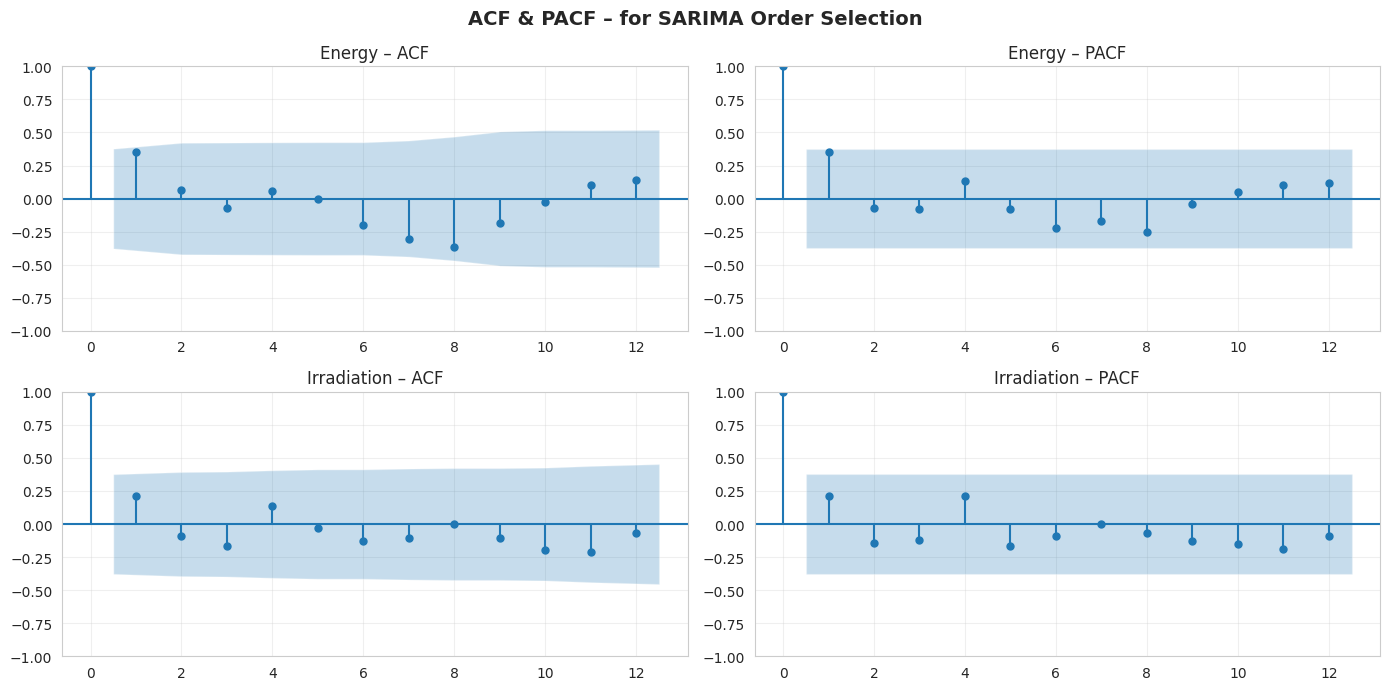

✅ ACF/PACF saved: acf_pacf_plots.png


In [19]:
# ── CELL F2: Prepare Forecasting DataFrames ──────────────────
# NOTE: daily_kpis must already exist from Cell 11 of main pipeline

# Convert DATE column to datetime if not already
daily_kpis['DATE'] = pd.to_datetime(daily_kpis['DATE'])
daily_kpis = daily_kpis.sort_values('DATE').reset_index(drop=True)

# ── Train/Test Split ─────────────────────────────────────────
# 34 days total → train on first 27 days, test on last 7
TRAIN_DAYS = 27
TEST_DAYS  = 7

train_df = daily_kpis.iloc[:TRAIN_DAYS].copy()
test_df  = daily_kpis.iloc[TRAIN_DAYS:].copy()

print(f"Train period : {train_df['DATE'].min().date()} → {train_df['DATE'].max().date()}  ({len(train_df)} days)")
print(f"Test period  : {test_df['DATE'].min().date()}  → {test_df['DATE'].max().date()}  ({len(test_df)} days)")
print(f"Forecast horizon : {TEST_DAYS} days ahead")


# ── CELL F3: Stationarity Check (ADF Test) ───────────────────
def adf_test(series, name):
    result = adfuller(series.dropna())
    p_val  = result[1]
    stat   = "STATIONARY ✅" if p_val < 0.05 else "NON-STATIONARY ⚠️"
    print(f"  {name:<30} ADF p-value = {p_val:.4f}  →  {stat}")

print("=== Augmented Dickey-Fuller Stationarity Test ===")
adf_test(train_df['TOTAL_ENERGY_KWH'], "Daily Energy (kWh)")
adf_test(train_df['AVG_IRRADIATION'],  "Avg Irradiation")

# ACF / PACF plots to guide SARIMA order selection
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("ACF & PACF – for SARIMA Order Selection", fontsize=14, fontweight='bold')

# Cap lags to 50% of series length minus 1 (statsmodels requirement)
max_lags = len(train_df) // 2 - 1

plot_acf( train_df['TOTAL_ENERGY_KWH'].dropna(), lags=max_lags, ax=axes[0][0], title="Energy – ACF")
plot_pacf(train_df['TOTAL_ENERGY_KWH'].dropna(), lags=max_lags, ax=axes[0][1], title="Energy – PACF")
plot_acf( train_df['AVG_IRRADIATION'].dropna(),  lags=max_lags, ax=axes[1][0], title="Irradiation – ACF")
plot_pacf(train_df['AVG_IRRADIATION'].dropna(),  lags=max_lags, ax=axes[1][1], title="Irradiation – PACF")

plt.tight_layout()
plt.savefig("acf_pacf_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ACF/PACF saved: acf_pacf_plots.png")


In [20]:
# ── CELL F4: PROPHET – Daily Energy Forecast ─────────────────
print("\n" + "="*50)
print("   PROPHET – Daily Energy Output Forecast")
print("="*50)

# Prophet requires columns named 'ds' and 'y'
prop_energy_train = train_df.rename(columns={'DATE': 'ds', 'TOTAL_ENERGY_KWH': 'y'})[['ds','y']]
prop_energy_full  = daily_kpis.rename(columns={'DATE': 'ds', 'TOTAL_ENERGY_KWH': 'y'})[['ds','y']]

# Build & fit model
prophet_energy = Prophet(
    yearly_seasonality  = False,   # only 34 days — no full year
    weekly_seasonality  = True,    # solar output varies day-of-week
    daily_seasonality   = False,   # daily-level data, not intra-day
    seasonality_mode    = 'multiplicative',
    changepoint_prior_scale = 0.1,
    interval_width      = 0.90
)
prophet_energy.fit(prop_energy_train)

# Forecast: future = test period + 7 extra days beyond data
future_energy  = prophet_energy.make_future_dataframe(periods=TEST_DAYS + 7, freq='D')
forecast_energy = prophet_energy.predict(future_energy)

# Extract test-period predictions
pred_energy = forecast_energy[forecast_energy['ds'].isin(test_df['DATE'])]['yhat'].values
actual_energy = test_df['TOTAL_ENERGY_KWH'].values

# Metrics
mae_e  = mean_absolute_error(actual_energy, pred_energy)
rmse_e = np.sqrt(mean_squared_error(actual_energy, pred_energy))
mape_e = np.mean(np.abs((actual_energy - pred_energy) / actual_energy)) * 100

print(f"\n  Prophet – Energy Forecast Metrics (Test Set):")
print(f"  MAE  : {mae_e:,.1f} kWh")
print(f"  RMSE : {rmse_e:,.1f} kWh")
print(f"  MAPE : {mape_e:.2f}%")



   PROPHET – Daily Energy Output Forecast


INFO:prophet:n_changepoints greater than number of observations. Using 20.



  Prophet – Energy Forecast Metrics (Test Set):
  MAE  : 33.8 kWh
  RMSE : 37.8 kWh
  MAPE : 25.17%


In [21]:
# ── CELL F5: PROPHET – Irradiation Forecast ──────────────────
print("\n" + "="*50)
print("   PROPHET – Irradiation Forecast")
print("="*50)

prop_irr_train = train_df.rename(columns={'DATE': 'ds', 'AVG_IRRADIATION': 'y'})[['ds','y']]

prophet_irr = Prophet(
    yearly_seasonality   = False,
    weekly_seasonality   = True,
    daily_seasonality    = False,
    seasonality_mode     = 'multiplicative',
    changepoint_prior_scale = 0.05,
    interval_width       = 0.90
)
prophet_irr.fit(prop_irr_train)

future_irr    = prophet_irr.make_future_dataframe(periods=TEST_DAYS + 7, freq='D')
forecast_irr  = prophet_irr.predict(future_irr)

pred_irr    = forecast_irr[forecast_irr['ds'].isin(test_df['DATE'])]['yhat'].values
actual_irr  = test_df['AVG_IRRADIATION'].values

mae_i  = mean_absolute_error(actual_irr, pred_irr)
rmse_i = np.sqrt(mean_squared_error(actual_irr, pred_irr))
mape_i = np.mean(np.abs((actual_irr - pred_irr) / (actual_irr + 1e-9))) * 100

print(f"\n  Prophet – Irradiation Forecast Metrics (Test Set):")
print(f"  MAE  : {mae_i:.4f} W/m²")
print(f"  RMSE : {rmse_i:.4f} W/m²")
print(f"  MAPE : {mape_i:.2f}%")



INFO:prophet:n_changepoints greater than number of observations. Using 20.



   PROPHET – Irradiation Forecast

  Prophet – Irradiation Forecast Metrics (Test Set):
  MAE  : 0.0572 W/m²
  RMSE : 0.0715 W/m²
  MAPE : 32.20%


In [22]:
# ── CELL F6: SARIMA – Daily Energy Forecast ──────────────────
print("\n" + "="*50)
print("   SARIMA – Daily Energy Output Forecast")
print("="*50)

# SARIMA(p,d,q)(P,D,Q,s)
# order=(1,1,1) — AR(1), 1 diff, MA(1)
# seasonal_order=(1,0,1,7) — weekly seasonality (s=7)
sarima_energy = SARIMAX(
    train_df['TOTAL_ENERGY_KWH'],
    order          = (1, 1, 1),
    seasonal_order = (1, 0, 1, 7),
    enforce_stationarity  = False,
    enforce_invertibility = False
).fit(disp=False)

print(sarima_energy.summary().tables[0])



   SARIMA – Daily Energy Output Forecast
                                     SARIMAX Results                                     
Dep. Variable:                  TOTAL_ENERGY_KWH   No. Observations:                   27
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood                 -73.945
Date:                           Wed, 04 Mar 2026   AIC                            157.889
Time:                                   08:07:53   BIC                            162.055
Sample:                                        0   HQIC                           158.304
                                            - 27                                         
Covariance Type:                             opg                                         


In [23]:
sarima_energy_pred = sarima_energy.forecast(steps=TEST_DAYS)
sarima_energy_pred = sarima_energy_pred.values

mae_se  = mean_absolute_error(actual_energy, sarima_energy_pred)
rmse_se = np.sqrt(mean_squared_error(actual_energy, sarima_energy_pred))
mape_se = np.mean(np.abs((actual_energy - sarima_energy_pred) / actual_energy)) * 100

print(f"\n  SARIMA – Energy Forecast Metrics (Test Set):")
print(f"  MAE  : {mae_se:,.1f} kWh")
print(f"  RMSE : {rmse_se:,.1f} kWh")
print(f"  MAPE : {mape_se:.2f}%")



  SARIMA – Energy Forecast Metrics (Test Set):
  MAE  : 23.0 kWh
  RMSE : 26.4 kWh
  MAPE : 17.08%


In [24]:
print("\n" + "="*50)
print("   SARIMA – Irradiation Forecast")
print("="*50)

sarima_irr = SARIMAX(
    train_df['AVG_IRRADIATION'],
    order          = (1, 1, 1),
    seasonal_order = (1, 0, 1, 7),
    enforce_stationarity  = False,
    enforce_invertibility = False
).fit(disp=False)

sarima_irr_pred = sarima_irr.forecast(steps=TEST_DAYS).values

mae_si  = mean_absolute_error(actual_irr, sarima_irr_pred)
rmse_si = np.sqrt(mean_squared_error(actual_irr, sarima_irr_pred))
mape_si = np.mean(np.abs((actual_irr - sarima_irr_pred) / (actual_irr + 1e-9))) * 100

print(f"\n  SARIMA – Irradiation Forecast Metrics (Test Set):")
print(f"  MAE  : {mae_si:.4f} W/m²")
print(f"  RMSE : {rmse_si:.4f} W/m²")
print(f"  MAPE : {mape_si:.2f}%")



   SARIMA – Irradiation Forecast

  SARIMA – Irradiation Forecast Metrics (Test Set):
  MAE  : 0.0462 W/m²
  RMSE : 0.0475 W/m²
  MAPE : 24.58%


In [25]:
comparison = pd.DataFrame({
    'Target'    : ['Daily Energy (kWh)', 'Daily Energy (kWh)',
                   'Irradiation',         'Irradiation'],
    'Model'     : ['Prophet', 'SARIMA', 'Prophet', 'SARIMA'],
    'MAE'       : [mae_e,  mae_se,  mae_i,  mae_si],
    'RMSE'      : [rmse_e, rmse_se, rmse_i, rmse_si],
    'MAPE (%)'  : [mape_e, mape_se, mape_i, mape_si]
})
comparison['MAE']      = comparison['MAE'].round(2)
comparison['RMSE']     = comparison['RMSE'].round(2)
comparison['MAPE (%)'] = comparison['MAPE (%)'].round(2)

print("\n=== MODEL COMPARISON TABLE ===")
display(comparison)

# Best model per target
for target in comparison['Target'].unique():
    subset = comparison[comparison['Target'] == target]
    best   = subset.loc[subset['MAPE (%)'].idxmin(), 'Model']
    print(f"  Best model for {target:<25}: {best}")




=== MODEL COMPARISON TABLE ===


,Target,Model,MAE,RMSE,MAPE (%)
0,Daily Energy (kWh),Prophet,33.82,37.79,25.17
1,Daily Energy (kWh),SARIMA,23.01,26.37,17.08
2,Irradiation,Prophet,0.06,0.07,32.20
3,Irradiation,SARIMA,0.05,0.05,24.58


  Best model for Daily Energy (kWh)       : SARIMA
  Best model for Irradiation              : SARIMA


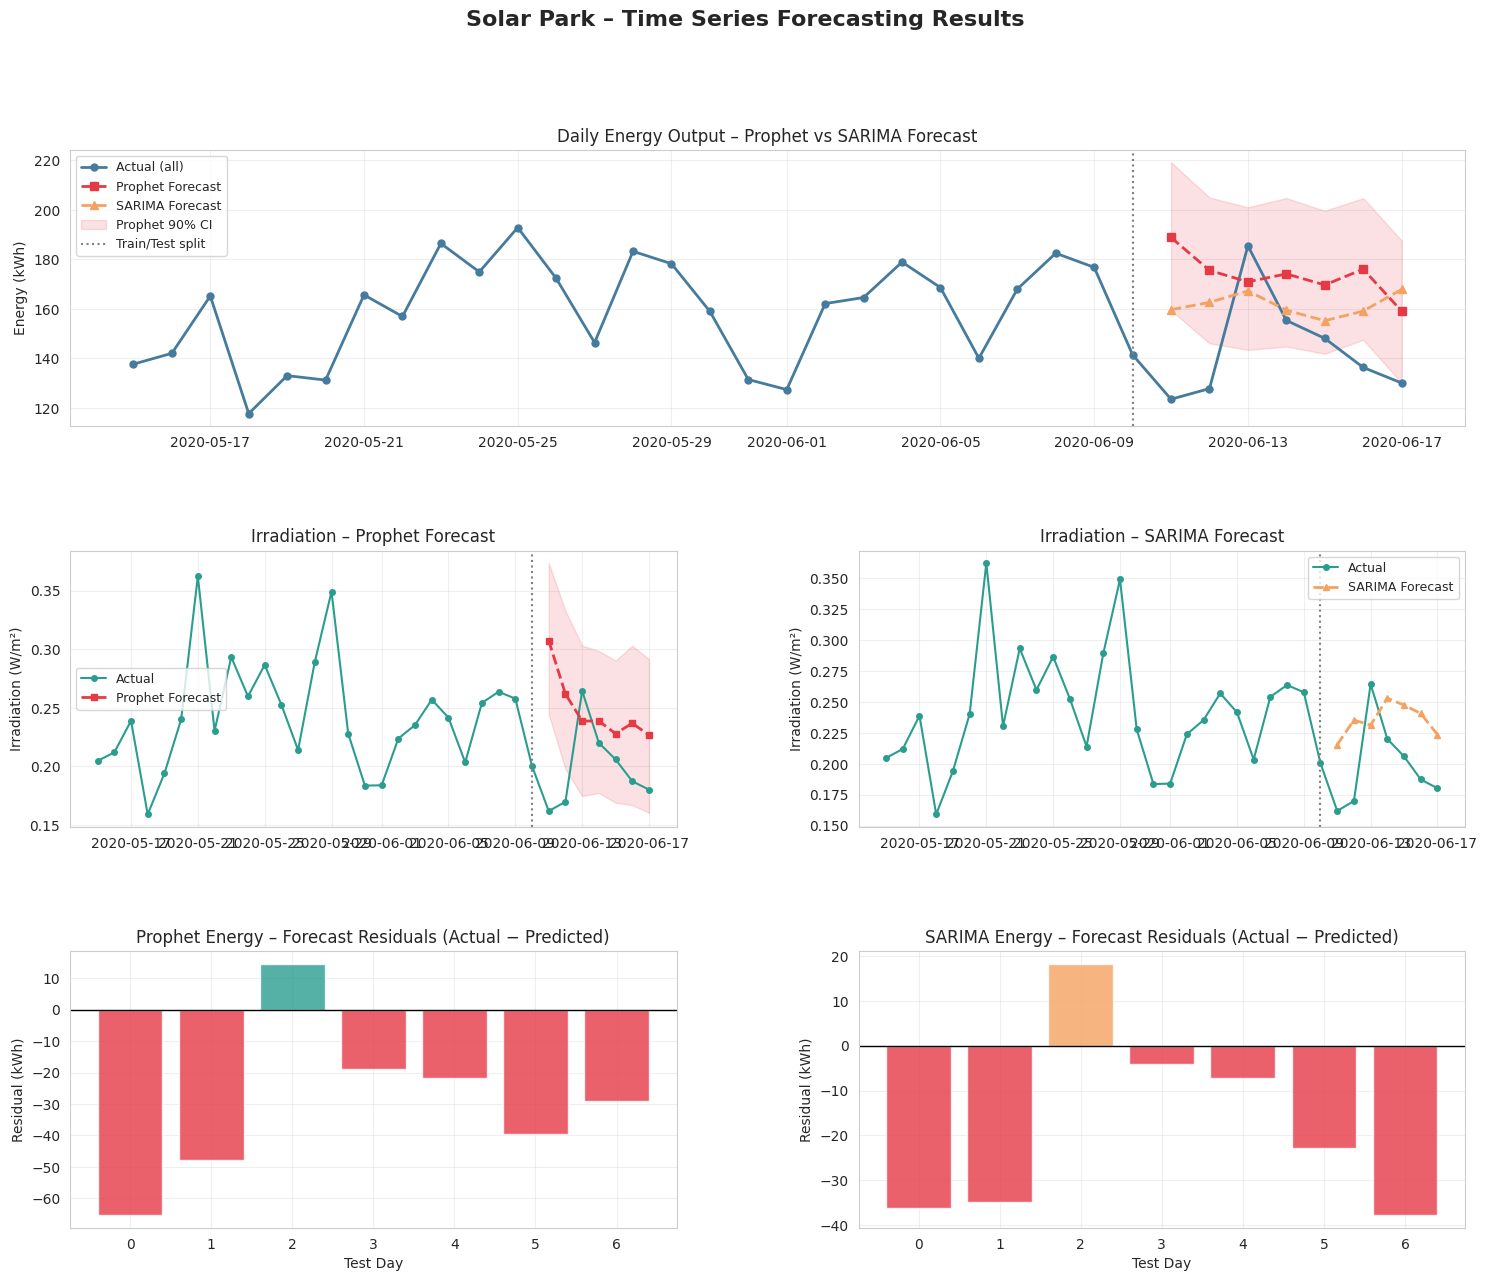

✅ Forecast plot saved: forecast_results.png


In [26]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle("Solar Park – Time Series Forecasting Results", fontsize=16, fontweight='bold')

test_dates = pd.to_datetime(test_df['DATE'].values)

# ── Panel 1: Prophet Energy – full forecast with CI ──────────
ax1 = fig.add_subplot(gs[0, :])
hist_dates = pd.to_datetime(daily_kpis['DATE'].values)
ax1.plot(hist_dates, daily_kpis['TOTAL_ENERGY_KWH'],
         'o-', color='#457b9d', lw=2, ms=5, label='Actual (all)')
ax1.plot(test_dates, pred_energy,
         's--', color='#e63946', lw=2, ms=6, label='Prophet Forecast')
ax1.plot(test_dates, sarima_energy_pred,
         '^--', color='#f4a261', lw=2, ms=6, label='SARIMA Forecast')

# Prophet confidence interval on test window
ci_rows = forecast_energy[forecast_energy['ds'].isin(test_df['DATE'])]
ax1.fill_between(pd.to_datetime(ci_rows['ds']),
                 ci_rows['yhat_lower'], ci_rows['yhat_upper'],
                 alpha=0.15, color='#e63946', label='Prophet 90% CI')
ax1.axvline(x=train_df['DATE'].max(), color='gray',
            linestyle=':', lw=1.5, label='Train/Test split')
ax1.set_title("Daily Energy Output – Prophet vs SARIMA Forecast")
ax1.set_ylabel("Energy (kWh)")
ax1.legend(fontsize=9)

# ── Panel 2: Prophet Irradiation forecast ────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(hist_dates, daily_kpis['AVG_IRRADIATION'],
         'o-', color='#2a9d8f', lw=1.5, ms=4, label='Actual')
ax2.plot(test_dates, pred_irr,
         's--', color='#e63946', lw=2, ms=5, label='Prophet Forecast')
ci_irr = forecast_irr[forecast_irr['ds'].isin(test_df['DATE'])]
ax2.fill_between(pd.to_datetime(ci_irr['ds']),
                 ci_irr['yhat_lower'].clip(0), ci_irr['yhat_upper'],
                 alpha=0.15, color='#e63946')
ax2.axvline(x=train_df['DATE'].max(), color='gray', linestyle=':', lw=1.5)
ax2.set_title("Irradiation – Prophet Forecast")
ax2.set_ylabel("Irradiation (W/m²)")
ax2.legend(fontsize=9)

# ── Panel 3: SARIMA Irradiation forecast ─────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(hist_dates, daily_kpis['AVG_IRRADIATION'],
         'o-', color='#2a9d8f', lw=1.5, ms=4, label='Actual')
ax3.plot(test_dates, sarima_irr_pred,
         '^--', color='#f4a261', lw=2, ms=5, label='SARIMA Forecast')
ax3.axvline(x=train_df['DATE'].max(), color='gray', linestyle=':', lw=1.5)
ax3.set_title("Irradiation – SARIMA Forecast")
ax3.set_ylabel("Irradiation (W/m²)")
ax3.legend(fontsize=9)

# ── Panel 4: Residuals – Prophet Energy ──────────────────────
ax4 = fig.add_subplot(gs[2, 0])
residuals_prop = actual_energy - pred_energy
ax4.bar(range(TEST_DAYS), residuals_prop,
        color=['#e63946' if r < 0 else '#2a9d8f' for r in residuals_prop], alpha=0.8)
ax4.axhline(0, color='black', lw=1)
ax4.set_title("Prophet Energy – Forecast Residuals (Actual − Predicted)")
ax4.set_ylabel("Residual (kWh)")
ax4.set_xlabel("Test Day")

# ── Panel 5: Residuals – SARIMA Energy ───────────────────────
ax5 = fig.add_subplot(gs[2, 1])
residuals_sarima = actual_energy - sarima_energy_pred
ax5.bar(range(TEST_DAYS), residuals_sarima,
        color=['#e63946' if r < 0 else '#f4a261' for r in residuals_sarima], alpha=0.8)
ax5.axhline(0, color='black', lw=1)
ax5.set_title("SARIMA Energy – Forecast Residuals (Actual − Predicted)")
ax5.set_ylabel("Residual (kWh)")
ax5.set_xlabel("Test Day")

plt.savefig("forecast_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Forecast plot saved: forecast_results.png")



Prophet Trend & Seasonality Decomposition – Energy:


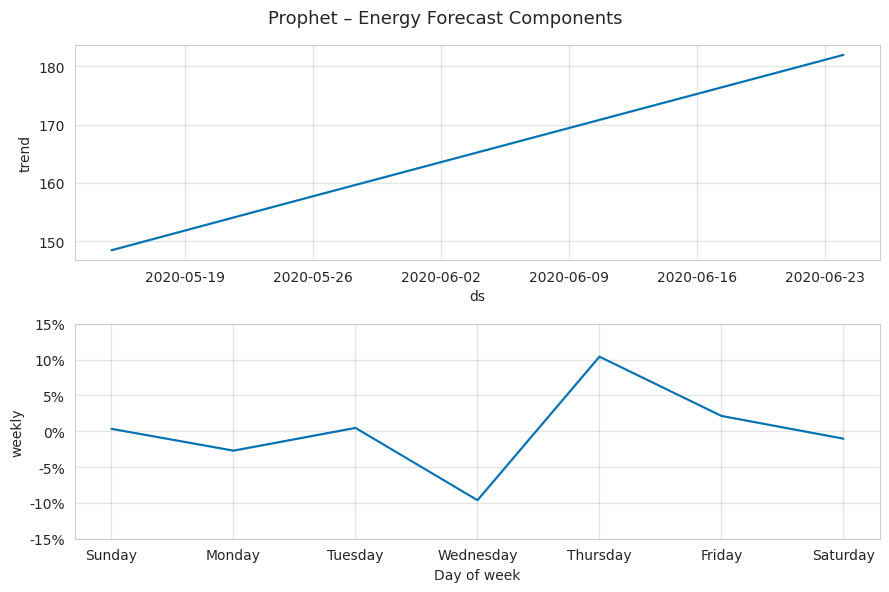


Prophet Trend & Seasonality Decomposition – Irradiation:


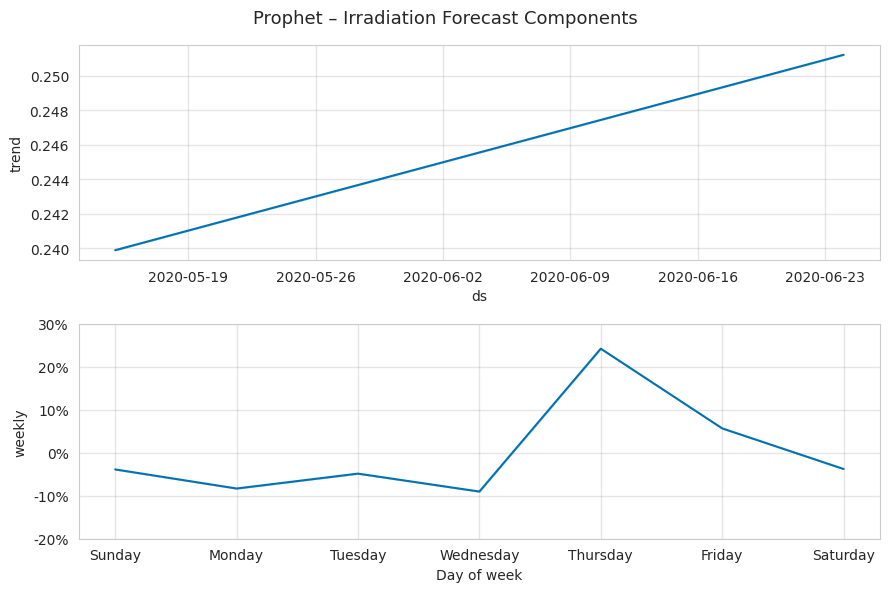

✅ Forecast outputs exported:
   • Plant1_Forecast_Results.csv  — actual vs predicted for test period
   • Plant1_Model_Comparison.csv  — MAE / RMSE / MAPE comparison table


,DATE,ACTUAL_ENERGY_KWH,ACTUAL_IRRADIATION,PROPHET_ENERGY_KWH,SARIMA_ENERGY_KWH,PROPHET_IRRADIATION,SARIMA_IRRADIATION,ENERGY_ERROR_PROPHET,ENERGY_ERROR_SARIMA
27,2020-06-11,123.543716,0.161809,188.88,159.70,0.3074,0.2154,-65.34,-36.16
28,2020-06-12,127.822424,0.169808,175.58,162.65,0.2619,0.2353,-47.76,-34.83
29,2020-06-13,185.508163,0.264472,170.96,167.28,0.2387,0.2312,14.55,18.23
30,2020-06-14,155.377324,0.220086,174.16,159.53,0.2387,0.2530,-18.78,-4.15
31,2020-06-15,148.120966,0.205925,169.70,155.24,0.2280,0.2474,-21.58,-7.12
32,2020-06-16,136.376670,0.187283,176.07,159.15,0.2368,0.2407,-39.69,-22.77
33,2020-06-17,130.095884,0.180157,159.14,167.88,0.2267,0.2236,-29.04,-37.78


In [27]:
print("\nProphet Trend & Seasonality Decomposition – Energy:")
fig_comp = prophet_energy.plot_components(forecast_energy)
fig_comp.suptitle("Prophet – Energy Forecast Components", fontsize=13)
plt.tight_layout()
plt.savefig("prophet_components_energy.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nProphet Trend & Seasonality Decomposition – Irradiation:")
fig_comp2 = prophet_irr.plot_components(forecast_irr)
fig_comp2.suptitle("Prophet – Irradiation Forecast Components", fontsize=13)
plt.tight_layout()
plt.savefig("prophet_components_irr.png", dpi=150, bbox_inches='tight')
plt.show()


# ── CELL F11: Export Forecast Results ───────────────────────
# Combine all forecasts into one export
forecast_export = test_df[['DATE','TOTAL_ENERGY_KWH','AVG_IRRADIATION']].copy()
forecast_export.columns = ['DATE','ACTUAL_ENERGY_KWH','ACTUAL_IRRADIATION']
forecast_export['PROPHET_ENERGY_KWH']   = pred_energy.round(2)
forecast_export['SARIMA_ENERGY_KWH']    = sarima_energy_pred.round(2)
forecast_export['PROPHET_IRRADIATION']  = pred_irr.round(4)
forecast_export['SARIMA_IRRADIATION']   = sarima_irr_pred.round(4)
forecast_export['ENERGY_ERROR_PROPHET'] = (forecast_export['ACTUAL_ENERGY_KWH'] - forecast_export['PROPHET_ENERGY_KWH']).round(2)
forecast_export['ENERGY_ERROR_SARIMA']  = (forecast_export['ACTUAL_ENERGY_KWH'] - forecast_export['SARIMA_ENERGY_KWH']).round(2)

forecast_export.to_csv("Plant1_Forecast_Results.csv", index=False)
comparison.to_csv("Plant1_Model_Comparison.csv", index=False)

print("✅ Forecast outputs exported:")
print("   • Plant1_Forecast_Results.csv  — actual vs predicted for test period")
print("   • Plant1_Model_Comparison.csv  — MAE / RMSE / MAPE comparison table")

display(forecast_export)


In [29]:
pip install streamlit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 47.0 MB/s eta 0:00:00


In [31]:
# ============================================================
#  SOLAR PARK OPTIMIZATION DASHBOARD  –  Streamlit App
#  Run: streamlit run solar_dashboard.py
#  Requires: Plant1_Cleaned_Merged.csv, Plant1_Daily_KPIs.csv,
#            Plant1_Inverter_KPIs.csv, Plant1_PlantLevel_TimeSeries.csv
#            (all exported from the Colab pipeline)
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# ── PAGE CONFIG ──────────────────────────────────────────────
st.set_page_config(
    page_title="Solar Park Optimization",
    page_icon="⚡",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── CUSTOM CSS ───────────────────────────────────────────────
st.markdown("""
<style>
  @import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:wght@300;400;500;600&display=swap');

  html, body, [class*="css"] { font-family: 'DM Sans', sans-serif; }

  .stApp { background: #0a0f1e; color: #e8eaf0; }

  /* Sidebar */
  [data-testid="stSidebar"] {
    background: #0d1424 !important;
    border-right: 1px solid #1e2a45;
  }
  [data-testid="stSidebar"] * { color: #c8d0e0 !important; }

  /* KPI Cards */
  .kpi-card {
    background: linear-gradient(135deg, #111827 0%, #1a2540 100%);
    border: 1px solid #1e3a5f;
    border-radius: 12px;
    padding: 20px 24px;
    text-align: center;
    position: relative;
    overflow: hidden;
  }
  .kpi-card::before {
    content: '';
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 3px;
    background: linear-gradient(90deg, #00d4ff, #0088ff);
  }
  .kpi-card.warning::before { background: linear-gradient(90deg, #ff6b35, #ff8c42); }
  .kpi-card.good::before    { background: linear-gradient(90deg, #00c97a, #00e891); }
  .kpi-card.neutral::before { background: linear-gradient(90deg, #a78bfa, #c4b5fd); }

  .kpi-label {
    font-family: 'Space Mono', monospace;
    font-size: 10px;
    letter-spacing: 2px;
    text-transform: uppercase;
    color: #6b7a9a;
    margin-bottom: 8px;
  }
  .kpi-value {
    font-family: 'Space Mono', monospace;
    font-size: 28px;
    font-weight: 700;
    color: #e8eaf0;
    line-height: 1;
  }
  .kpi-sub {
    font-size: 12px;
    color: #4a5680;
    margin-top: 6px;
  }

  /* Section headers */
  .section-header {
    font-family: 'Space Mono', monospace;
    font-size: 11px;
    letter-spacing: 3px;
    text-transform: uppercase;
    color: #00d4ff;
    margin: 32px 0 16px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #1e2a45;
  }

  /* Alert badges */
  .badge-red   { background:#ff4444; color:#fff; padding:2px 10px; border-radius:20px; font-size:11px; font-weight:600; }
  .badge-amber { background:#ff9800; color:#fff; padding:2px 10px; border-radius:20px; font-size:11px; font-weight:600; }
  .badge-green { background:#00c97a; color:#fff; padding:2px 10px; border-radius:20px; font-size:11px; font-weight:600; }

  /* Plotly chart containers */
  .chart-container {
    background: #111827;
    border: 1px solid #1e2a45;
    border-radius: 12px;
    padding: 4px;
    margin-bottom: 16px;
  }

  /* Page title */
  .page-title {
    font-family: 'Space Mono', monospace;
    font-size: 22px;
    font-weight: 700;
    color: #e8eaf0;
    letter-spacing: 1px;
  }
  .page-sub {
    font-family: 'DM Sans', sans-serif;
    font-size: 13px;
    color: #4a5680;
    margin-top: 2px;
  }

  div[data-testid="stSelectbox"] label,
  div[data-testid="stMultiSelect"] label,
  div[data-testid="stDateInput"] label,
  .stSlider label { color: #6b7a9a !important; font-size: 12px !important; letter-spacing: 1px; }

  /* Tab styling */
  .stTabs [data-baseweb="tab-list"] { background: #0d1424; border-bottom: 1px solid #1e2a45; gap: 4px; }
  .stTabs [data-baseweb="tab"] { background: transparent; color: #4a5680; font-family: 'Space Mono', monospace; font-size: 11px; letter-spacing: 1px; border-radius: 6px 6px 0 0; }
  .stTabs [aria-selected="true"] { background: #111827 !important; color: #00d4ff !important; border-bottom: 2px solid #00d4ff; }

  /* Metric delta */
  [data-testid="stMetricDelta"] { font-size: 11px; }

  /* Divider */
  hr { border-color: #1e2a45; }
</style>
""", unsafe_allow_html=True)

# ── PLOTLY THEME ─────────────────────────────────────────────
PLOTLY_LAYOUT = dict(
    paper_bgcolor="#111827",
    plot_bgcolor="#111827",
    font=dict(family="DM Sans", color="#8892aa", size=12),
    margin=dict(l=12, r=12, t=40, b=12),
    legend=dict(bgcolor="rgba(0,0,0,0)", bordercolor="#1e2a45", font=dict(size=11)),
)
# Reusable axis style dict
AXIS = dict(gridcolor="#1a2540", linecolor="#1e2a45", tickfont=dict(size=11))
COLORS = {
    "primary":  "#00d4ff",
    "accent":   "#0088ff",
    "green":    "#00c97a",
    "amber":    "#ff9800",
    "red":      "#ff4444",
    "purple":   "#a78bfa",
    "muted":    "#2a3a5a",
    "setpoint": "#ff6b35",
}

# ── DATA LOADING ─────────────────────────────────────────────
@st.cache_data
def load_data():
    merged    = pd.read_csv("Plant1_Cleaned_Merged.csv", parse_dates=["DATE_TIME"])
    daily     = pd.read_csv("Plant1_Daily_KPIs.csv",     parse_dates=["DATE"])
    inverters = pd.read_csv("Plant1_Inverter_KPIs.csv")
    plant_ts  = pd.read_csv("Plant1_PlantLevel_TimeSeries.csv", parse_dates=["DATE_TIME"])
    plant_ts["DATE"] = pd.to_datetime(plant_ts["DATE"])
    merged["DATE"]   = pd.to_datetime(merged["DATE"])
    return merged, daily, inverters, plant_ts

try:
    merged_df, daily_kpis, inverter_kpis, plant_ts = load_data()
    data_loaded = True
except FileNotFoundError:
    data_loaded = False

# ── SIDEBAR ──────────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style='padding:16px 0 24px 0'>
      <div style='font-family:Space Mono,monospace;font-size:16px;font-weight:700;color:#00d4ff;'>⚡ SOLAR OPS</div>
      <div style='font-size:11px;color:#4a5680;letter-spacing:2px;margin-top:4px;'>PLANT 1 · INDIA</div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("---")
    st.markdown("<div style='font-family:Space Mono,monospace;font-size:10px;letter-spacing:2px;color:#4a5680;margin-bottom:12px;'>NAVIGATION</div>", unsafe_allow_html=True)

    page = st.radio("", [
        "🏠  Overview",
        "📈  Time Series",
        "🔋  Inverter Health",
        "⚙️  Optimization",
        "🌤️  Weather Correlation",
    ], label_visibility="collapsed")

    if data_loaded:
        st.markdown("---")
        st.markdown("<div style='font-family:Space Mono,monospace;font-size:10px;letter-spacing:2px;color:#4a5680;margin-bottom:12px;'>FILTERS</div>", unsafe_allow_html=True)

        all_dates = sorted(daily_kpis["DATE"].dt.date.unique())
        date_range = st.select_slider(
            "Date Range",
            options=all_dates,
            value=(all_dates[0], all_dates[-1])
        )

        all_inverters = sorted(merged_df["SOURCE_KEY"].unique())
        selected_inverters = st.multiselect(
            "Inverters",
            options=all_inverters,
            default=all_inverters[:5],
            placeholder="Select inverters…"
        )
        if not selected_inverters:
            selected_inverters = all_inverters

        st.markdown("---")
        st.markdown(f"""
        <div style='font-size:11px;color:#4a5680;line-height:1.8;'>
          <div>📅 Period: <span style='color:#8892aa'>{all_dates[0]} → {all_dates[-1]}</span></div>
          <div>🔋 Inverters: <span style='color:#8892aa'>{len(all_inverters)}</span></div>
          <div>📊 Records: <span style='color:#8892aa'>{len(merged_df):,}</span></div>
          <div>⏱ Interval: <span style='color:#8892aa'>15 min</span></div>
        </div>
        """, unsafe_allow_html=True)

# ── GUARD: no data ───────────────────────────────────────────
if not data_loaded:
    st.error("⚠️  CSV files not found. Run the Colab pipeline first and place the 4 output CSVs in the same folder as this script.")
    st.stop()

# ── FILTER DATA ──────────────────────────────────────────────
filt_daily   = daily_kpis[(daily_kpis["DATE"].dt.date >= date_range[0]) &
                           (daily_kpis["DATE"].dt.date <= date_range[1])]
filt_plant   = plant_ts[(plant_ts["DATE"].dt.date >= date_range[0]) &
                         (plant_ts["DATE"].dt.date <= date_range[1])]
filt_merged  = merged_df[(merged_df["DATE"].dt.date >= date_range[0]) &
                          (merged_df["DATE"].dt.date <= date_range[1]) &
                          (merged_df["SOURCE_KEY"].isin(selected_inverters))]


# ════════════════════════════════════════════════════════════
#  PAGE 1 – OVERVIEW
# ════════════════════════════════════════════════════════════
if page == "🏠  Overview":

    st.markdown("""
    <div style='margin-bottom:28px'>
      <div class='page-title'>PLANT OVERVIEW</div>
      <div class='page-sub'>Real-time KPIs · Performance · Alerts · Energy Summary</div>
    </div>
    """, unsafe_allow_html=True)

    # ── KPI Row ──────────────────────────────────────────────
    total_energy   = filt_daily["TOTAL_ENERGY_KWH"].sum()
    expected_energy= filt_daily["EXPECTED_ENERGY_KWH"].sum()
    energy_loss    = filt_daily["ENERGY_LOSS_KWH"].sum()
    avg_pr         = filt_daily["PERFORMANCE_RATIO"].mean() * 100
    avg_eff        = filt_merged[filt_merged["IS_DAYTIME"]]["CONVERSION_EFFICIENCY"].mean() * 100
    underperf_total= filt_daily["TOTAL_UNDERPERFORMANCE"].sum()
    curtail_total  = filt_daily["TOTAL_CURTAILMENT"].sum()
    peak_power     = filt_daily["PEAK_AC_POWER_KW"].max()

    c1, c2, c3, c4 = st.columns(4)
    with c1:
        st.markdown(f"""<div class='kpi-card good'>
          <div class='kpi-label'>Total Energy</div>
          <div class='kpi-value'>{total_energy/1000:.1f} <span style='font-size:14px'>MWh</span></div>
          <div class='kpi-sub'>Expected: {expected_energy/1000:.1f} MWh</div>
        </div>""", unsafe_allow_html=True)
    with c2:
        pr_class = "good" if avg_pr >= 85 else ("warning" if avg_pr >= 70 else "kpi-card")
        st.markdown(f"""<div class='kpi-card {pr_class}'>
          <div class='kpi-label'>Avg Performance Ratio</div>
          <div class='kpi-value'>{avg_pr:.1f}<span style='font-size:14px'>%</span></div>
          <div class='kpi-sub'>Target: ≥85%</div>
        </div>""", unsafe_allow_html=True)
    with c3:
        st.markdown(f"""<div class='kpi-card warning'>
          <div class='kpi-label'>Energy Loss</div>
          <div class='kpi-value'>{energy_loss/1000:.1f} <span style='font-size:14px'>MWh</span></div>
          <div class='kpi-sub'>{(energy_loss/expected_energy*100) if expected_energy>0 else 0:.1f}% of expected</div>
        </div>""", unsafe_allow_html=True)
    with c4:
        st.markdown(f"""<div class='kpi-card neutral'>
          <div class='kpi-label'>Conversion Efficiency</div>
          <div class='kpi-value'>{avg_eff:.1f}<span style='font-size:14px'>%</span></div>
          <div class='kpi-sub'>DC → AC</div>
        </div>""", unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    c5, c6, c7, c8 = st.columns(4)
    with c5:
        st.markdown(f"""<div class='kpi-card'>
          <div class='kpi-label'>Peak AC Power</div>
          <div class='kpi-value'>{peak_power:.1f} <span style='font-size:14px'>kW</span></div>
          <div class='kpi-sub'>All inverters combined</div>
        </div>""", unsafe_allow_html=True)
    with c6:
        st.markdown(f"""<div class='kpi-card warning'>
          <div class='kpi-label'>Underperf Events</div>
          <div class='kpi-value'>{int(underperf_total):,}</div>
          <div class='kpi-sub'>&gt;10% below setpoint</div>
        </div>""", unsafe_allow_html=True)
    with c7:
        st.markdown(f"""<div class='kpi-card warning'>
          <div class='kpi-label'>Curtailment Events</div>
          <div class='kpi-value'>{int(curtail_total):,}</div>
          <div class='kpi-sub'>Daytime near-zero output</div>
        </div>""", unsafe_allow_html=True)
    with c8:
        st.markdown(f"""<div class='kpi-card'>
          <div class='kpi-label'>Active Inverters</div>
          <div class='kpi-value'>{len(all_inverters)}</div>
          <div class='kpi-sub'>Monitored units</div>
        </div>""", unsafe_allow_html=True)

    st.markdown("<div class='section-header'>DAILY ENERGY — ACTUAL VS EXPECTED</div>", unsafe_allow_html=True)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=filt_daily["DATE"], y=filt_daily["EXPECTED_ENERGY_KWH"]/1000,
        name="Expected", marker_color=COLORS["muted"], opacity=0.6
    ))
    fig.add_trace(go.Bar(
        x=filt_daily["DATE"], y=filt_daily["TOTAL_ENERGY_KWH"]/1000,
        name="Actual", marker_color=COLORS["primary"], opacity=0.9
    ))
    fig.add_trace(go.Scatter(
        x=filt_daily["DATE"], y=filt_daily["PERFORMANCE_RATIO"]*100,
        name="Performance Ratio (%)", yaxis="y2",
        line=dict(color=COLORS["amber"], width=2), mode="lines+markers",
        marker=dict(size=5)
    ))
    fig.update_layout(
        **PLOTLY_LAYOUT,
        barmode="overlay",
        yaxis=dict(**AXIS, title="Energy (MWh)"),
        yaxis2=dict(overlaying="y", side="right", title="PR (%)",
                    gridcolor="rgba(0,0,0,0)", tickfont=dict(size=11, color=COLORS["amber"])),
        height=320, title="Daily Energy Output vs Setpoint Target"
    )
    st.plotly_chart(fig, use_container_width=True)

    # ── Energy Loss + Alerts side by side ────────────────────
    col_left, col_right = st.columns([2, 1])

    with col_left:
        st.markdown("<div class='section-header'>ENERGY LOSS BY DAY</div>", unsafe_allow_html=True)
        fig2 = go.Figure(go.Bar(
            x=filt_daily["DATE"],
            y=filt_daily["ENERGY_LOSS_KWH"],
            marker=dict(
                color=filt_daily["ENERGY_LOSS_KWH"],
                colorscale=[[0,"#1a2540"],[0.5, COLORS["amber"]],[1, COLORS["red"]]],
                showscale=True,
                colorbar=dict(title="kWh", tickfont=dict(size=10))
            )
        ))
        fig2.update_layout(**PLOTLY_LAYOUT, height=260,
                           yaxis=dict(**AXIS, title="Lost Energy (kWh)"),
                           title="Daily Energy Loss (Actual vs Expected Gap)")
        st.plotly_chart(fig2, use_container_width=True)

    with col_right:
        st.markdown("<div class='section-header'>OPERATIONAL ALERTS</div>", unsafe_allow_html=True)
        # Worst performing days
        worst = filt_daily.nsmallest(5, "PERFORMANCE_RATIO")[["DATE","PERFORMANCE_RATIO","ENERGY_LOSS_KWH"]]
        for _, row in worst.iterrows():
            pr_pct = row["PERFORMANCE_RATIO"] * 100
            badge  = "badge-red" if pr_pct < 70 else "badge-amber"
            st.markdown(f"""
            <div style='background:#111827;border:1px solid #1e2a45;border-radius:8px;
                        padding:10px 14px;margin-bottom:8px;'>
              <div style='display:flex;justify-content:space-between;align-items:center;'>
                <div style='font-size:12px;color:#8892aa;'>{str(row['DATE'])[:10]}</div>
                <span class='{badge}'>{pr_pct:.0f}%</span>
              </div>
              <div style='font-size:11px;color:#4a5680;margin-top:4px;'>
                Loss: {row['ENERGY_LOSS_KWH']:,.0f} kWh
              </div>
            </div>
            """, unsafe_allow_html=True)


# ════════════════════════════════════════════════════════════
#  PAGE 2 – TIME SERIES
# ════════════════════════════════════════════════════════════
elif page == "📈  Time Series":

    st.markdown("""
    <div style='margin-bottom:28px'>
      <div class='page-title'>TIME SERIES ANALYSIS</div>
      <div class='page-sub'>Plant-level power · Setpoints · Deviations · 15-minute SCADA data</div>
    </div>
    """, unsafe_allow_html=True)

    tab1, tab2, tab3 = st.tabs(["  POWER OUTPUT  ", "  DEVIATIONS  ", "  INTRA-DAY PROFILE  "])

    with tab1:
        # Date selector for single-day drill-down
        selected_date = st.select_slider(
            "Select Day for Drill-Down",
            options=sorted(filt_plant["DATE"].dt.date.unique())
        )
        day_data = filt_plant[filt_plant["DATE"].dt.date == selected_date]

        fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                            row_heights=[0.65, 0.35], vertical_spacing=0.06)

        fig.add_trace(go.Scatter(
            x=day_data["DATE_TIME"], y=day_data["TOTAL_AC_POWER"]/1000,
            name="Actual AC Power", fill="tozeroy",
            fillcolor="rgba(0,212,255,0.08)", line=dict(color=COLORS["primary"], width=2)
        ), row=1, col=1)
        fig.add_trace(go.Scatter(
            x=day_data["DATE_TIME"], y=day_data["TOTAL_SETPOINT"]/1000,
            name="Setpoint", line=dict(color=COLORS["setpoint"], width=1.5, dash="dash")
        ), row=1, col=1)
        fig.add_trace(go.Scatter(
            x=day_data["DATE_TIME"], y=day_data["TOTAL_DC_POWER"]/1000,
            name="DC Power", line=dict(color=COLORS["purple"], width=1, dash="dot"), opacity=0.7
        ), row=1, col=1)

        fig.add_trace(go.Bar(
            x=day_data["DATE_TIME"], y=day_data["PLANT_DEVIATION_PCT"],
            name="Deviation %",
            marker_color=[COLORS["red"] if v < -10 else COLORS["green"] if v > 0 else COLORS["amber"]
                          for v in day_data["PLANT_DEVIATION_PCT"].fillna(0)],
            opacity=0.8
        ), row=2, col=1)
        fig.add_hline(y=-10, line_dash="dot", line_color=COLORS["red"], row=2, col=1,
                      annotation_text="-10% threshold", annotation_font_size=10)

        fig.update_layout(
            **PLOTLY_LAYOUT, height=460,
            title=f"AC Power vs Setpoint — {selected_date}",
            yaxis=dict(**AXIS, title="Power (kW)"),
            yaxis2=dict(**AXIS, title="Deviation (%)"),
        )
        st.plotly_chart(fig, use_container_width=True)

        # Full period overview
        st.markdown("<div class='section-header'>FULL PERIOD — PLANT POWER OVERVIEW</div>", unsafe_allow_html=True)
        fig_full = go.Figure()
        fig_full.add_trace(go.Scatter(
            x=filt_plant["DATE_TIME"], y=filt_plant["TOTAL_AC_POWER"]/1000,
            name="Actual AC", fill="tozeroy",
            fillcolor="rgba(0,212,255,0.05)", line=dict(color=COLORS["primary"], width=1)
        ))
        fig_full.add_trace(go.Scatter(
            x=filt_plant["DATE_TIME"], y=filt_plant["TOTAL_SETPOINT"]/1000,
            name="Setpoint", line=dict(color=COLORS["setpoint"], width=1, dash="dash"), opacity=0.6
        ))
        fig_full.update_layout(**PLOTLY_LAYOUT, height=250,
                               yaxis=dict(**AXIS, title="Power (kW)"))
        st.plotly_chart(fig_full, use_container_width=True)

    with tab2:
        st.markdown("<div class='section-header'>DEVIATION FROM SETPOINT — INVERTER LEVEL</div>", unsafe_allow_html=True)

        inv_sel = st.selectbox("Select Inverter", selected_inverters)
        inv_data = filt_merged[filt_merged["SOURCE_KEY"] == inv_sel].copy()

        fig_dev = make_subplots(rows=2, cols=1, shared_xaxes=True,
                                row_heights=[0.5, 0.5], vertical_spacing=0.06)
        fig_dev.add_trace(go.Scatter(
            x=inv_data["DATE_TIME"], y=inv_data["AC_POWER"],
            name="AC Power", line=dict(color=COLORS["primary"], width=1)
        ), row=1, col=1)
        fig_dev.add_trace(go.Scatter(
            x=inv_data["DATE_TIME"], y=inv_data["SETPOINT_AC_POWER"],
            name="Setpoint", line=dict(color=COLORS["setpoint"], width=1, dash="dash")
        ), row=1, col=1)

        # Deviation scatter coloured by flag
        colours_dev = [
            COLORS["red"] if u else COLORS["amber"] if c else COLORS["green"]
            for u, c in zip(inv_data["UNDERPERFORMANCE_FLAG"], inv_data["CURTAILMENT_FLAG"])
        ]
        fig_dev.add_trace(go.Scatter(
            x=inv_data["DATE_TIME"], y=inv_data["DEVIATION_PCT"],
            mode="markers", name="Deviation %",
            marker=dict(color=colours_dev, size=3, opacity=0.7)
        ), row=2, col=1)
        fig_dev.add_hline(y=-10, line_dash="dot", line_color=COLORS["red"],   row=2, col=1)
        fig_dev.add_hline(y=15,  line_dash="dot", line_color=COLORS["amber"], row=2, col=1)
        fig_dev.add_hline(y=0,   line_color="#2a3a5a", row=2, col=1)

        fig_dev.update_layout(**PLOTLY_LAYOUT, height=430,
                              title=f"Inverter {inv_sel} — Power & Deviation",
                              yaxis=dict(**AXIS, title="AC Power (W)"),
                              yaxis2=dict(**AXIS, title="Deviation (%)"))
        st.plotly_chart(fig_dev, use_container_width=True)

        # Flag summary
        c1, c2, c3 = st.columns(3)
        with c1:
            n_under = int(inv_data["UNDERPERFORMANCE_FLAG"].sum())
            st.markdown(f"""<div class='kpi-card warning'>
              <div class='kpi-label'>Underperformance</div>
              <div class='kpi-value'>{n_under:,}</div>
              <div class='kpi-sub'>events &gt;10% below setpoint</div>
            </div>""", unsafe_allow_html=True)
        with c2:
            n_curt = int(inv_data["CURTAILMENT_FLAG"].sum())
            st.markdown(f"""<div class='kpi-card warning'>
              <div class='kpi-label'>Curtailment</div>
              <div class='kpi-value'>{n_curt:,}</div>
              <div class='kpi-sub'>daytime near-zero events</div>
            </div>""", unsafe_allow_html=True)
        with c3:
            eff = inv_data[inv_data["IS_DAYTIME"]]["CONVERSION_EFFICIENCY"].mean()*100
            st.markdown(f"""<div class='kpi-card good'>
              <div class='kpi-label'>Avg Efficiency</div>
              <div class='kpi-value'>{eff:.1f}%</div>
              <div class='kpi-sub'>DC → AC conversion</div>
            </div>""", unsafe_allow_html=True)

    with tab3:
        st.markdown("<div class='section-header'>AVERAGE INTRA-DAY POWER PROFILE</div>", unsafe_allow_html=True)

        hourly = filt_plant.groupby(filt_plant["DATE_TIME"].dt.hour).agg(
            AVG_AC=("TOTAL_AC_POWER","mean"),
            P10_AC=("TOTAL_AC_POWER", lambda x: x.quantile(0.1)),
            P90_AC=("TOTAL_AC_POWER", lambda x: x.quantile(0.9)),
            AVG_SET=("TOTAL_SETPOINT","mean"),
            AVG_IRR=("IRRADIATION","mean"),
        ).reset_index().rename(columns={"DATE_TIME":"HOUR"})

        fig_hr = go.Figure()
        fig_hr.add_trace(go.Scatter(
            x=hourly["HOUR"], y=hourly["P90_AC"]/1000,
            fill=None, mode="lines", line=dict(color="rgba(0,212,255,0.1)"), showlegend=False
        ))
        fig_hr.add_trace(go.Scatter(
            x=hourly["HOUR"], y=hourly["P10_AC"]/1000,
            fill="tonexty", fillcolor="rgba(0,212,255,0.08)",
            mode="lines", line=dict(color="rgba(0,212,255,0.1)"), name="P10–P90 Band"
        ))
        fig_hr.add_trace(go.Scatter(
            x=hourly["HOUR"], y=hourly["AVG_AC"]/1000,
            name="Avg AC Power", line=dict(color=COLORS["primary"], width=2.5),
            mode="lines+markers", marker=dict(size=6)
        ))
        fig_hr.add_trace(go.Scatter(
            x=hourly["HOUR"], y=hourly["AVG_SET"]/1000,
            name="Avg Setpoint", line=dict(color=COLORS["setpoint"], width=1.5, dash="dash")
        ))
        fig_hr.update_layout(
            **PLOTLY_LAYOUT, height=320,
            xaxis=dict(**AXIS, title="Hour of Day",
                       tickvals=list(range(0,24,2))),
            yaxis=dict(**AXIS, title="Power (kW)"),
            title="Average Hourly Power Profile (All Days)"
        )
        st.plotly_chart(fig_hr, use_container_width=True)

        # Hourly heatmap over all days
        st.markdown("<div class='section-header'>HOUR × DAY POWER HEATMAP</div>", unsafe_allow_html=True)
        hm_data = filt_plant.copy()
        hm_data["HOUR"] = hm_data["DATE_TIME"].dt.hour
        hm_data["DAY"]  = hm_data["DATE_TIME"].dt.date.astype(str)
        hm_pivot = hm_data.pivot_table(values="TOTAL_AC_POWER", index="HOUR", columns="DAY", aggfunc="mean") / 1000

        fig_hm = go.Figure(go.Heatmap(
            z=hm_pivot.values, x=hm_pivot.columns, y=hm_pivot.index,
            colorscale=[[0,"#0a0f1e"],[0.3,"#0d2a4a"],[0.6,COLORS["accent"]],[1,COLORS["primary"]]],
            colorbar=dict(title="kW", tickfont=dict(size=10, color="#8892aa"))
        ))
        fig_hm.update_layout(
            **PLOTLY_LAYOUT, height=340,
            xaxis=dict(**AXIS, title="Date"),
            yaxis=dict(**AXIS, title="Hour of Day"),
            title="Plant AC Power – Hour × Day Heatmap (kW)"
        )
        st.plotly_chart(fig_hm, use_container_width=True)


# ════════════════════════════════════════════════════════════
#  PAGE 3 – INVERTER HEALTH
# ════════════════════════════════════════════════════════════
elif page == "🔋  Inverter Health":

    st.markdown("""
    <div style='margin-bottom:28px'>
      <div class='page-title'>INVERTER HEALTH & RANKING</div>
      <div class='page-sub'>Comparative performance · Efficiency · Fault detection</div>
    </div>
    """, unsafe_allow_html=True)

    # ── Ranking chart ────────────────────────────────────────
    st.markdown("<div class='section-header'>INVERTER ENERGY RANKING</div>", unsafe_allow_html=True)

    inv_sorted = inverter_kpis.sort_values("TOTAL_ENERGY_KWH", ascending=True)
    bar_colors = [COLORS["red"] if r > 20 else COLORS["primary"] for r in inv_sorted["UNDERPERF_RATE_PCT"]]

    fig_rank = go.Figure(go.Bar(
        x=inv_sorted["TOTAL_ENERGY_KWH"],
        y=inv_sorted["SOURCE_KEY"],
        orientation="h",
        marker_color=bar_colors,
        text=inv_sorted["TOTAL_ENERGY_KWH"].apply(lambda x: f"{x:,.0f} kWh"),
        textposition="outside",
        textfont=dict(size=10, color="#8892aa")
    ))
    fig_rank.update_layout(
        **PLOTLY_LAYOUT, height=520,
        xaxis=dict(**AXIS, title="Total Energy Generated (kWh)"),
        yaxis=dict(**AXIS, title=""),
        title="Total Energy by Inverter  (🔴 = underperformance rate > 20%)"
    )
    st.plotly_chart(fig_rank, use_container_width=True)

    # ── Efficiency vs Underperformance Scatter ────────────────
    col1, col2 = st.columns(2)

    with col1:
        st.markdown("<div class='section-header'>EFFICIENCY VS UNDERPERF RATE</div>", unsafe_allow_html=True)
        fig_sc = px.scatter(
            inverter_kpis,
            x="UNDERPERF_RATE_PCT", y="AVG_EFFICIENCY",
            size="TOTAL_ENERGY_KWH", color="UNDERPERF_RATE_PCT",
            color_continuous_scale=[[0, COLORS["green"]], [0.5, COLORS["amber"]], [1, COLORS["red"]]],
            hover_data=["SOURCE_KEY","TOTAL_ENERGY_KWH","CURTAILMENT_EVENTS"],
            text="SOURCE_KEY"
        )
        fig_sc.update_traces(textposition="top center", textfont=dict(size=8, color="#8892aa"))
        fig_sc.update_layout(
            **PLOTLY_LAYOUT, height=340,
            xaxis=dict(**AXIS, title="Underperformance Rate (%)"),
            yaxis=dict(**AXIS, title="Avg Conversion Efficiency"),
            coloraxis_showscale=False,
            title="Efficiency vs Underperformance (bubble = energy)"
        )
        st.plotly_chart(fig_sc, use_container_width=True)

    with col2:
        st.markdown("<div class='section-header'>INVERTER HEATMAP — DAILY AC POWER</div>", unsafe_allow_html=True)
        pivot_inv = filt_merged.pivot_table(
            values="AC_POWER", index="SOURCE_KEY",
            columns=filt_merged["DATE"].dt.strftime("%m-%d"),
            aggfunc="sum"
        ) / 1000

        fig_inv_hm = go.Figure(go.Heatmap(
            z=pivot_inv.values, x=pivot_inv.columns, y=pivot_inv.index,
            colorscale=[[0,"#0a0f1e"],[0.4,"#0d2a4a"],[0.7,COLORS["accent"]],[1,COLORS["primary"]]],
            colorbar=dict(title="kWh", tickfont=dict(size=9, color="#8892aa"))
        ))
        fig_inv_hm.update_layout(
            **PLOTLY_LAYOUT, height=340,
            xaxis=dict(**AXIS, title="Date", tickfont=dict(size=9)),
            yaxis=dict(**AXIS, title="", tickfont=dict(size=9)),
            title="Inverter Daily Output Heatmap (kWh)"
        )
        st.plotly_chart(fig_inv_hm, use_container_width=True)

    # ── Detailed table ────────────────────────────────────────
    st.markdown("<div class='section-header'>INVERTER DETAIL TABLE</div>", unsafe_allow_html=True)
    display_inv = inverter_kpis.copy()
    display_inv["AVG_EFFICIENCY"] = (display_inv["AVG_EFFICIENCY"] * 100).round(2)
    display_inv["TOTAL_ENERGY_KWH"] = display_inv["TOTAL_ENERGY_KWH"].round(1)
    display_inv["UNDERPERF_RATE_PCT"] = display_inv["UNDERPERF_RATE_PCT"].round(2)
    display_inv = display_inv.rename(columns={
        "SOURCE_KEY":"Inverter","TOTAL_ENERGY_KWH":"Energy (kWh)",
        "AVG_EFFICIENCY":"Efficiency (%)","UNDERPERF_RATE_PCT":"Underperf Rate (%)",
        "CURTAILMENT_EVENTS":"Curtailment Events","AVG_AC_POWER":"Avg AC Power (W)"
    })

    def colour_row(val):
        if isinstance(val, float) and val > 20:
            return "color: #ff4444"
        return ""

    st.dataframe(
        display_inv.style.applymap(colour_row, subset=["Underperf Rate (%)"]),
        use_container_width=True, height=340
    )


# ════════════════════════════════════════════════════════════
#  PAGE 4 – OPTIMIZATION
# ════════════════════════════════════════════════════════════
elif page == "⚙️  Optimization":

    st.markdown("""
    <div style='margin-bottom:28px'>
      <div class='page-title'>PRODUCTION OPTIMIZATION</div>
      <div class='page-sub'>Expected vs Actual · Constraint evaluation · Loss attribution</div>
    </div>
    """, unsafe_allow_html=True)

    # ── Top-level deviation gauge ────────────────────────────
    avg_dev = filt_plant["PLANT_DEVIATION_PCT"].mean()
    col1, col2 = st.columns([1, 2])

    with col1:
        fig_gauge = go.Figure(go.Indicator(
            mode="gauge+number+delta",
            value=avg_dev,
            delta={"reference": 0, "valueformat": ".1f"},
            number={"suffix": "%", "font": {"size": 36, "color": "#e8eaf0", "family": "Space Mono"}},
            gauge={
                "axis": {"range": [-30, 20], "tickfont": {"size": 10, "color": "#4a5680"}},
                "bar": {"color": COLORS["primary"], "thickness": 0.25},
                "bgcolor": "#111827",
                "bordercolor": "#1e2a45",
                "steps": [
                    {"range": [-30, -10], "color": "rgba(255,68,68,0.2)"},
                    {"range": [-10, 0],   "color": "rgba(255,152,0,0.15)"},
                    {"range": [0, 20],    "color": "rgba(0,201,122,0.1)"},
                ],
                "threshold": {"line": {"color": COLORS["red"], "width": 2}, "value": -10}
            },
            title={"text": "Avg Plant Deviation<br>from Setpoint",
                   "font": {"size": 12, "color": "#6b7a9a", "family": "Space Mono"}}
        ))
        fig_gauge.update_layout(paper_bgcolor="#111827", height=260,
                                margin=dict(l=20, r=20, t=20, b=10))
        st.plotly_chart(fig_gauge, use_container_width=True)

    with col2:
        st.markdown("<div class='section-header'>DEVIATION DISTRIBUTION</div>", unsafe_allow_html=True)
        day_dev = filt_merged[filt_merged["IS_DAYTIME"] & filt_merged["DEVIATION_PCT"].notna()]
        fig_hist = go.Figure()
        fig_hist.add_trace(go.Histogram(
            x=day_dev["DEVIATION_PCT"],
            nbinsx=60, name="Deviation %",
            marker_color=COLORS["primary"], opacity=0.75
        ))
        fig_hist.add_vline(x=-10, line_dash="dot", line_color=COLORS["red"],
                           annotation_text="Underperf threshold (-10%)",
                           annotation_font=dict(size=10, color=COLORS["red"]))
        fig_hist.add_vline(x=0, line_color="#2a3a5a")
        fig_hist.update_layout(
            **PLOTLY_LAYOUT, height=240,
            xaxis=dict(**AXIS, title="Deviation from Setpoint (%)"),
            yaxis=dict(**AXIS, title="Count"),
            title="Distribution of Inverter Deviations (Daytime Only)"
        )
        st.plotly_chart(fig_hist, use_container_width=True)

    # ── Flag timeline ────────────────────────────────────────
    st.markdown("<div class='section-header'>CONSTRAINT & FLAG TIMELINE</div>", unsafe_allow_html=True)

    flag_daily = filt_merged.groupby("DATE").agg(
        UNDERPERF=("UNDERPERFORMANCE_FLAG","sum"),
        CURTAIL  =("CURTAILMENT_FLAG","sum"),
        OVERLOAD =("OVERLOAD_FLAG","sum"),
    ).reset_index()

    fig_flags = go.Figure()
    fig_flags.add_trace(go.Bar(x=flag_daily["DATE"], y=flag_daily["UNDERPERF"],
                               name="Underperformance", marker_color=COLORS["red"], opacity=0.85))
    fig_flags.add_trace(go.Bar(x=flag_daily["DATE"], y=flag_daily["CURTAIL"],
                               name="Curtailment", marker_color=COLORS["amber"], opacity=0.85))
    fig_flags.add_trace(go.Bar(x=flag_daily["DATE"], y=flag_daily["OVERLOAD"],
                               name="Overload", marker_color=COLORS["purple"], opacity=0.85))
    fig_flags.update_layout(
        **PLOTLY_LAYOUT, barmode="stack", height=290,
        yaxis=dict(**AXIS, title="Event Count"),
        title="Daily Operational Flags — Underperformance · Curtailment · Overload"
    )
    st.plotly_chart(fig_flags, use_container_width=True)

    # ── Loss attribution waterfall ────────────────────────────
    st.markdown("<div class='section-header'>ENERGY LOSS ATTRIBUTION</div>", unsafe_allow_html=True)

    total_exp  = filt_daily["EXPECTED_ENERGY_KWH"].sum()
    total_act  = filt_daily["TOTAL_ENERGY_KWH"].sum()
    under_loss = filt_daily["TOTAL_UNDERPERFORMANCE"].sum() * 0.25 * (15/60) / 1000  # rough proxy
    curt_loss  = filt_daily["TOTAL_CURTAILMENT"].sum()     * 0.15 * (15/60) / 1000
    other_loss = max(0, (total_exp - total_act)/1000 - under_loss - curt_loss)

    fig_wf = go.Figure(go.Waterfall(
        orientation="v",
        measure=["absolute","relative","relative","relative","total"],
        x=["Expected Energy","Underperformance Loss","Curtailment Loss","Other Loss","Actual Energy"],
        y=[total_exp/1000, -under_loss, -curt_loss, -other_loss, 0],
        connector={"line": {"color": "#1e2a45"}},
        decreasing={"marker": {"color": COLORS["red"]}},
        increasing={"marker": {"color": COLORS["green"]}},
        totals={"marker": {"color": COLORS["primary"]}},
        text=[f"{total_exp/1000:.1f} MWh","","","",f"{total_act/1000:.1f} MWh"],
        textposition="outside"
    ))
    fig_wf.update_layout(
        **PLOTLY_LAYOUT, height=320,
        yaxis=dict(**AXIS, title="Energy (MWh)"),
        title="Energy Loss Waterfall — Expected → Actual"
    )
    st.plotly_chart(fig_wf, use_container_width=True)


# ════════════════════════════════════════════════════════════
#  PAGE 5 – WEATHER CORRELATION
# ════════════════════════════════════════════════════════════
elif page == "🌤️  Weather Correlation":

    st.markdown("""
    <div style='margin-bottom:28px'>
      <div class='page-title'>WEATHER CORRELATION</div>
      <div class='page-sub'>Irradiation · Temperature · Power response · Environmental analysis</div>
    </div>
    """, unsafe_allow_html=True)

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("<div class='section-header'>IRRADIATION vs AC POWER</div>", unsafe_allow_html=True)
        day_data = filt_plant[filt_plant["TOTAL_AC_POWER"] > 0]
        fig_irr = px.scatter(
            day_data, x="IRRADIATION", y="TOTAL_AC_POWER",
            color="AMBIENT_TEMPERATURE",
            color_continuous_scale=[[0,"#0d2a4a"],[0.5,COLORS["accent"]],[1,COLORS["red"]]],
            opacity=0.6, trendline="ols"
        )
        fig_irr.update_traces(marker=dict(size=4))
        fig_irr.update_layout(
            **PLOTLY_LAYOUT, height=320,
            xaxis=dict(**AXIS, title="Irradiation (W/m²)"),
            yaxis=dict(**AXIS, title="Total AC Power (W)"),
            coloraxis_colorbar=dict(title="Temp °C", tickfont=dict(size=9)),
            title="Irradiation vs AC Power (colour = ambient temp)"
        )
        st.plotly_chart(fig_irr, use_container_width=True)

    with col2:
        st.markdown("<div class='section-header'>MODULE TEMP vs EFFICIENCY</div>", unsafe_allow_html=True)
        eff_data = filt_plant[filt_plant["AVG_CONVERSION_EFF"].notna() &
                               (filt_plant["TOTAL_AC_POWER"] > 0)]
        fig_temp = px.scatter(
            eff_data, x="MODULE_TEMPERATURE", y="AVG_CONVERSION_EFF",
            color="IRRADIATION",
            color_continuous_scale=[[0,"#0d2a4a"],[0.5,COLORS["amber"]],[1,"#ffeb3b"]],
            opacity=0.6, trendline="ols"
        )
        fig_temp.update_traces(marker=dict(size=4))
        fig_temp.update_layout(
            **PLOTLY_LAYOUT, height=320,
            xaxis=dict(**AXIS, title="Module Temperature (°C)"),
            yaxis=dict(**AXIS, title="Conversion Efficiency"),
            coloraxis_colorbar=dict(title="Irrad.", tickfont=dict(size=9)),
            title="Module Temp vs Efficiency (colour = irradiation)"
        )
        st.plotly_chart(fig_temp, use_container_width=True)

    # ── Weather time series ───────────────────────────────────
    st.markdown("<div class='section-header'>WEATHER TIME SERIES</div>", unsafe_allow_html=True)
    fig_wx = make_subplots(rows=3, cols=1, shared_xaxes=True,
                           row_heights=[0.4, 0.3, 0.3], vertical_spacing=0.04)
    fig_wx.add_trace(go.Scatter(
        x=filt_plant["DATE_TIME"], y=filt_plant["IRRADIATION"],
        fill="tozeroy", fillcolor="rgba(255,235,59,0.06)",
        line=dict(color="#ffeb3b", width=1.5), name="Irradiation"
    ), row=1, col=1)
    fig_wx.add_trace(go.Scatter(
        x=filt_plant["DATE_TIME"], y=filt_plant["AMBIENT_TEMPERATURE"],
        line=dict(color=COLORS["amber"], width=1.5), name="Ambient Temp"
    ), row=2, col=1)
    fig_wx.add_trace(go.Scatter(
        x=filt_plant["DATE_TIME"], y=filt_plant["MODULE_TEMPERATURE"],
        line=dict(color=COLORS["red"], width=1.5), name="Module Temp"
    ), row=2, col=1)
    fig_wx.add_trace(go.Scatter(
        x=filt_plant["DATE_TIME"], y=filt_plant["TOTAL_AC_POWER"]/1000,
        line=dict(color=COLORS["primary"], width=1.2), name="AC Power"
    ), row=3, col=1)
    fig_wx.update_layout(
        **PLOTLY_LAYOUT, height=480,
        title="Weather Parameters & AC Power — Full Period",
        yaxis =dict(**AXIS, title="Irradiation (W/m²)"),
        yaxis2=dict(**AXIS, title="Temperature (°C)"),
        yaxis3=dict(**AXIS, title="AC Power (kW)"),
    )
    st.plotly_chart(fig_wx, use_container_width=True)

    # ── Correlation matrix ────────────────────────────────────
    st.markdown("<div class='section-header'>FEATURE CORRELATION MATRIX</div>", unsafe_allow_html=True)
    corr_cols = ["TOTAL_AC_POWER","TOTAL_DC_POWER","IRRADIATION",
                 "AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","AVG_CONVERSION_EFF"]
    corr = filt_plant[corr_cols].corr().round(2)

    fig_corr = go.Figure(go.Heatmap(
        z=corr.values, x=corr.columns, y=corr.index,
        colorscale=[[0,COLORS["red"]],[0.5,"#111827"],[1,COLORS["primary"]]],
        zmid=0, zmin=-1, zmax=1,
        text=corr.values, texttemplate="%{text}",
        textfont=dict(size=11, color="#e8eaf0"),
        colorbar=dict(tickfont=dict(size=9, color="#8892aa"))
    ))
    fig_corr.update_layout(
        **PLOTLY_LAYOUT, height=370,
        xaxis=dict(**AXIS, tickfont=dict(size=10)),
        yaxis=dict(**AXIS, tickfont=dict(size=10)),
        title="Pearson Correlation — Power & Environmental Features"
    )
    st.plotly_chart(fig_corr, use_container_width=True)

# ── FOOTER ───────────────────────────────────────────────────
st.markdown("""
<div style='text-align:center;padding:32px 0 16px;
            font-family:Space Mono,monospace;font-size:10px;
            letter-spacing:2px;color:#1e2a45;'>
  SOLAR PARK OPTIMIZATION DASHBOARD · PLANT 1 · IGNITIS GROUP
</div>
""", unsafe_allow_html=True)

2026-03-04 08:16:17.123 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 08:16:17.125 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 08:16:17.126 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 08:16:17.126 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 08:16:17.128 No runtime found, using MemoryCacheStorageManager
2026-03-04 08:16:17.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 08:16:17.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 08:16:17.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-04 08:16:17.143 Thread 'MainThread':

DeltaGenerator()

In [39]:
!pip install streamlit pyngrok --quiet

from pyngrok import ngrok
ngrok.set_auth_token("3ATNaPj0k0tqMTo0KhBqaw50tDO_3pPDDMY5VjKkCqdvEU8FM")  # free token from https://ngrok.com

In [41]:
import subprocess, time
from pyngrok import ngrok

# Kill any existing streamlit processes
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

# Start Streamlit
process = subprocess.Popen(
    ["streamlit", "run", "solar_dashboard.py",
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Wait longer for it to fully start
print("⏳ Starting Streamlit...")
time.sleep(10)

# Check it's actually running
import urllib.request
try:
    urllib.request.urlopen("http://localhost:8501", timeout=5)
    print("✅ Streamlit is up!")
except Exception as e:
    print(f"⚠️ Streamlit check: {e} — trying anyway...")

# Connect ngrok
public_url = ngrok.connect(8501)
print(f"\n🚀 Dashboard live at: {public_url}")

⏳ Starting Streamlit...
⚠️ Streamlit check: <urlopen error [Errno 111] Connection refused> — trying anyway...

🚀 Dashboard live at: NgrokTunnel: "https://unrelishing-jaylynn-undemanding.ngrok-free.dev" -> "http://localhost:8501"


In [42]:
import subprocess, time

process = subprocess.Popen(
    ["streamlit", "run", "solar_dashboard.py",
     "--server.port", "8501",
     "--server.headless", "true"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(8)
process.poll()  # check if it crashed

stdout = process.stdout.read().decode()
stderr = process.stderr.read().decode()

print("=== STDOUT ===")
print(stdout[:3000])
print("=== STDERR ===")
print(stderr[:3000])
print("=== Return code ===", process.returncode)

=== STDOUT ===

=== STDERR ===
Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: solar_dashboard.py

=== Return code === 2


In [43]:
import os

# Find the file
for root, dirs, files in os.walk('/content'):
    for f in files:
        if 'solar' in f.lower():
            print(os.path.join(root, f))

In [44]:
import subprocess, time
from pyngrok import ngrok

subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

# Use full path
process = subprocess.Popen(
    ["streamlit", "run", "/content/solar_dashboard.py",  # ← full path
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("⏳ Starting Streamlit...")
time.sleep(10)

import urllib.request
try:
    urllib.request.urlopen("http://localhost:8501", timeout=5)
    print("✅ Streamlit is up!")
except:
    print("⚠️ Still not up — checking logs...")
    process.poll()
    print(process.stderr.read().decode()[:2000])

public_url = ngrok.connect(8501)
print(f"\n🚀 Dashboard live at: {public_url}")

⏳ Starting Streamlit...
⚠️ Still not up — checking logs...
Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: /content/solar_dashboard.py


🚀 Dashboard live at: NgrokTunnel: "https://unrelishing-jaylynn-undemanding.ngrok-free.dev" -> "http://localhost:8501"


In [48]:
from google.colab import files

# This opens a file picker — upload solar_dashboard.py AND all 4 CSVs
uploaded = files.upload()

Saving solar_dashboard_writefile.py to solar_dashboard_writefile.py


In [49]:
import subprocess, time
from pyngrok import ngrok

subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

# Use full path
process = subprocess.Popen(
    ["streamlit", "run", "/content/solar_dashboard.py",  # ← full path
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("⏳ Starting Streamlit...")
time.sleep(10)

import urllib.request
try:
    urllib.request.urlopen("http://localhost:8501", timeout=5)
    print("✅ Streamlit is up!")
except:
    print("⚠️ Still not up — checking logs...")
    process.poll()
    print(process.stderr.read().decode()[:2000])

public_url = ngrok.connect(8501)
print(f"\n🚀 Dashboard live at: {public_url}")

⏳ Starting Streamlit...
✅ Streamlit is up!

🚀 Dashboard live at: NgrokTunnel: "https://unrelishing-jaylynn-undemanding.ngrok-free.dev" -> "http://localhost:8501"
